# Model Predictions Viewer
Quick tool to view predictions from different models

In [1]:
# GPU Environment Setup
import os
import sys

# Set environment variables for GPU and threading
os.environ['SLURM_CPU_BIND'] = 'cores'
os.environ['NUMEXPR_MAX_THREADS'] = '128'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['TF_NUM_INTEROP_THREADS'] = '8'
os.environ['TF_NUM_INTRAOP_THREADS'] = '16'
os.environ['OMP_NUM_THREADS'] = '16'
os.environ['PYTHONUNBUFFERED'] = '1'

print("GPU environment configured!")
print(f"CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES', 'Not set')}")

# Verify GPU access
try:
    !nvidia-smi -L
except:
    print("Warning: nvidia-smi not available")

GPU environment configured!
CUDA_VISIBLE_DEVICES: 0
NVIDIA-SMI has failed because it couldn't communicate with the NVIDIA driver. Make sure that the latest NVIDIA driver is installed and running.



In [2]:
# Load and View Model Predictions
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


def view_predictions(model_name, n=10, base_path='../models'):
    """
    Load and display predictions from a model.
    
    Parameters:
    -----------
    model_name : str
        Name of the model folder under models/
    n : int
        Number of predictions to display (default: 10)
    base_path : str
        Base path to models directory (default: 'models')
    """
    # Construct path to predictions file
    pred_file = Path(base_path) / model_name / 'predictions.npz'
    
    if not pred_file.exists():
        print(f"❌ File not found: {pred_file}")
        return None
    
    # Load predictions
    print(f"📂 Loading: {pred_file}")
    data = np.load(pred_file)
    
    # Extract arrays
    y_true = data['y_true']
    y_pred = data['y_pred']
    errors = data['errors']
    
    # Check if new format with event metadata exists
    has_metadata = 'event_numbers' in data and 'file_indices' in data
    
    if has_metadata:
        event_numbers = data['event_numbers']
        file_indices = data['file_indices']
        
        # Create DataFrame with metadata
        df = pd.DataFrame({
            'Index': range(len(y_true)),
            'Event_Number': event_numbers,
            'File_Index': file_indices,
            'y_true': y_true,
            'y_pred': y_pred,
            'error': errors
        })
    else:
        # Legacy format without metadata
        df = pd.DataFrame({
            'Index': range(len(y_true)),
            'y_true': y_true,
            'y_pred': y_pred,
            'error': errors
        })
    
    # Print summary statistics
    print(f"\n📊 Summary Statistics for {model_name}")
    print(f"{'='*60}")
    print(f"Total samples: {len(y_true)}")
    if has_metadata:
        print(f"Format: New (with event metadata)")
        print(f"Unique files: {len(np.unique(file_indices))}")
    else:
        print(f"Format: Legacy (no event metadata)")
    
    print(f"\nError Statistics:")
    print(f"  Mean Error:   {errors.mean():.6f}")
    print(f"  Std Error:    {errors.std():.6f}")
    print(f"  Min Error:    {errors.min():.6f}")
    print(f"  Max Error:    {errors.max():.6f}")
    print(f"  Median Error: {np.median(errors):.6f}")
    
    # Display first n predictions
    print(f"\n📋 First {n} Predictions:")
    print(f"{'='*60}")
    display(df.head(n))
    
    return df


def verify_identical_ytrue(model1_name, model2_name, base_path='../models'):
    """
    Verify that y_true values are identical between two models.
    
    Parameters:
    -----------
    model1_name : str
        Name of the first model
    model2_name : str
        Name of the second model
    base_path : str
        Base path to models directory
    """
    # Load predictions from both models
    pred_file1 = Path(base_path) / model1_name / 'predictions.npz'
    pred_file2 = Path(base_path) / model2_name / 'predictions.npz'
    
    data1 = np.load(pred_file1)
    data2 = np.load(pred_file2)
    
    y_true1 = data1['y_true']
    y_true2 = data2['y_true']
    
    # Check if event metadata exists
    has_metadata1 = 'event_numbers' in data1 and 'file_indices' in data1
    has_metadata2 = 'event_numbers' in data2 and 'file_indices' in data2
    
    # Check size
    size_match = len(y_true1) == len(y_true2)
    print(f"✓ Size check: Model1={len(y_true1)}, Model2={len(y_true2)} → {'PASS' if size_match else 'FAIL'}")
    
    # Check values
    if size_match:
        values_match = np.allclose(y_true1, y_true2)
        exact_match = np.array_equal(y_true1, y_true2)
        
        print(f"✓ Values identical (exact): {'PASS ✅' if exact_match else 'FAIL ❌'}")
        
        if not exact_match:
            print(f"✓ Values close (tolerance): {'PASS ⚠️' if values_match else 'FAIL ❌'}")
            max_diff = np.abs(y_true1 - y_true2).max()
            print(f"  Max difference: {max_diff:.10f}")
        
        # If both have metadata, verify event alignment
        if has_metadata1 and has_metadata2:
            event_match = np.array_equal(data1['event_numbers'], data2['event_numbers'])
            file_match = np.array_equal(data1['file_indices'], data2['file_indices'])
            
            print(f"✓ Event numbers match: {'PASS ✅' if event_match else 'FAIL ❌'}")
            print(f"✓ File indices match: {'PASS ✅' if file_match else 'FAIL ❌'}")
            
            if not event_match or not file_match:
                print("⚠️  Warning: Event metadata doesn't match - models may be using different event samples!")
        elif has_metadata1 or has_metadata2:
            print("⚠️  Warning: Only one model has event metadata - cannot verify event alignment")
    else:
        print("❌ Cannot compare values - sizes don't match!")


def compare_model_errors_2d(model1_name, model2_name, 
                            model1_label=None, model2_label=None,
                            base_path='../models'):
    """
    Create 2D histograms comparing errors and predictions from two models.
    
    Parameters:
    -----------
    model1_name : str
        Name of the first model (x-axis)
    model2_name : str
        Name of the second model (y-axis)
    model1_label : str, optional
        Physical meaning label for model 1 (e.g., "LAr-only")
    model2_label : str, optional
        Physical meaning label for model 2 (e.g., "LAr+HGTD")
    base_path : str
        Base path to models directory
    """
    # Use model names as labels if not provided
    if model1_label is None:
        model1_label = model1_name
    if model2_label is None:
        model2_label = model2_name
    
    # Load predictions from both models
    pred_file1 = Path(base_path) / model1_name / 'predictions.npz'
    pred_file2 = Path(base_path) / model2_name / 'predictions.npz'
    
    if not pred_file1.exists():
        print(f"❌ File not found: {pred_file1}")
        return
    if not pred_file2.exists():
        print(f"❌ File not found: {pred_file2}")
        return
    
    # Load data
    data1 = np.load(pred_file1)
    data2 = np.load(pred_file2)
    
    errors1 = data1['errors']
    errors2 = data2['errors']
    y_pred1 = data1['y_pred']
    y_pred2 = data2['y_pred']
    
    # Check if event metadata exists
    has_metadata1 = 'event_numbers' in data1 and 'file_indices' in data1
    has_metadata2 = 'event_numbers' in data2 and 'file_indices' in data2
    
    # Verify event alignment if both have metadata
    if has_metadata1 and has_metadata2:
        event_match = np.array_equal(data1['event_numbers'], data2['event_numbers'])
        file_match = np.array_equal(data1['file_indices'], data2['file_indices'])
        
        if not (event_match and file_match):
            print("⚠️  Warning: Event metadata doesn't match between models!")
            print("    Comparison may not be meaningful if models used different events.")
    
    # Check if same number of samples
    if len(errors1) != len(errors2):
        print(f"⚠️ Warning: Different number of samples ({len(errors1)} vs {len(errors2)})")
        min_len = min(len(errors1), len(errors2))
        errors1 = errors1[:min_len]
        errors2 = errors2[:min_len]
        y_pred1 = y_pred1[:min_len]
        y_pred2 = y_pred2[:min_len]
    
    # Create figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # === Left plot: Error comparison (Delta t0) ===
    ax1 = axes[0]
    
    # Create 2D histogram for errors
    lim_min_err = min(errors1.min(), errors2.min())
    lim_max_err = max(errors1.max(), errors2.max())
    
    h1 = ax1.hist2d(errors1, errors2, bins=100, cmap='viridis', cmin=1)
    
    # Add colorbar
    cbar1 = plt.colorbar(h1[3], ax=ax1)
    cbar1.set_label('Count', fontsize=12)
    
    # Add diagonal line (y=x)
    ax1.plot([lim_min_err, lim_max_err], [lim_min_err, lim_max_err], 
             'r--', linewidth=2, label='y=x', alpha=0.7)
    
    # Add zero lines
    ax1.axhline(y=0, color='white', linestyle='--', linewidth=1, alpha=0.5)
    ax1.axvline(x=0, color='white', linestyle='--', linewidth=1, alpha=0.5)
    
    # Calculate correlation
    correlation_err = np.corrcoef(errors1, errors2)[0, 1]
    
    # Labels and title
    ax1.set_xlabel(f'{model1_label} $\\Delta t_0$ [ps]', fontsize=13, fontweight='bold')
    ax1.set_ylabel(f'{model2_label} $\\Delta t_0$ [ps]', fontsize=13, fontweight='bold')
    ax1.set_title('Error Comparison ($\\Delta t_0$)', fontsize=14, fontweight='bold', pad=20)
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Add correlation text
    ax1.text(0.95, 0.05, f'Corr: {correlation_err:.3f}', 
             transform=ax1.transAxes, fontsize=11, 
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # === Right plot: Prediction comparison (Predicted t0) ===
    ax2 = axes[1]
    
    # Create 2D histogram for predictions
    lim_min_pred = min(y_pred1.min(), y_pred2.min())
    lim_max_pred = max(y_pred1.max(), y_pred2.max())
    
    h2 = ax2.hist2d(y_pred1, y_pred2, bins=100, cmap='viridis', cmin=1)
    
    # Add colorbar
    cbar2 = plt.colorbar(h2[3], ax=ax2)
    cbar2.set_label('Count', fontsize=12)
    
    # Add diagonal line (y=x)
    ax2.plot([lim_min_pred, lim_max_pred], [lim_min_pred, lim_max_pred], 
             'r--', linewidth=2, label='y=x', alpha=0.7)
    
    # Calculate correlation
    correlation_pred = np.corrcoef(y_pred1, y_pred2)[0, 1]
    
    # Labels and title
    ax2.set_xlabel(f'{model1_label} Predicted $t_0$ [ps]', fontsize=13, fontweight='bold')
    ax2.set_ylabel(f'{model2_label} Predicted $t_0$ [ps]', fontsize=13, fontweight='bold')
    ax2.set_title('Prediction Comparison (Predicted $t_0$)', fontsize=14, fontweight='bold', pad=20)
    ax2.legend(loc='upper left', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # Add correlation text
    ax2.text(0.95, 0.05, f'Corr: {correlation_pred:.3f}', 
             transform=ax2.transAxes, fontsize=11, 
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n📊 Comparison Summary")
    print(f"{'='*60}")
    print(f"Model 1: {model1_label} ({model1_name})")
    print(f"  Mean Error: {errors1.mean():.4f} ps")
    print(f"  Std Error:  {errors1.std():.4f} ps")
    print(f"\nModel 2: {model2_label} ({model2_name})")
    print(f"  Mean Error: {errors2.mean():.4f} ps")
    print(f"  Std Error:  {errors2.std():.4f} ps")
    print(f"\nError Correlation: {correlation_err:.4f}")
    print(f"Prediction Correlation: {correlation_pred:.4f}")
    print(f"Total Samples: {len(errors1)}")

✓ Size check: Model1=8876, Model2=8876 → PASS
✓ Values identical (exact): PASS ✅
✓ Event numbers match: PASS ✅
✓ File indices match: PASS ✅
📂 Loading: ../models/hgtd_multi_input_dnn_with_jets_tracks/predictions.npz

📊 Summary Statistics for hgtd_multi_input_dnn_with_jets_tracks
Total samples: 8876
Format: New (with event metadata)
Unique files: 50

Error Statistics:
  Mean Error:   -0.494620
  Std Error:    73.423676
  Min Error:    -503.848877
  Max Error:    577.704468
  Median Error: -0.364219

📋 First 5 Predictions:


,Index,Event_Number,File_Index,y_true,y_pred,error
0,0,43170,34,-142.325104,-8.098275,134.226822
1,1,111671,9,-202.486069,-189.475845,13.010223
2,2,106679,44,-62.909557,-65.645531,-2.735973
3,3,99596,19,-52.310635,-56.101036,-3.790401
4,4,92459,23,-50.675278,-44.744549,5.930729




📂 Loading: ../models/test_1209_LAr/predictions.npz

📊 Summary Statistics for test_1209_LAr
Total samples: 8876
Format: New (with event metadata)
Unique files: 50

Error Statistics:
  Mean Error:   -7.740700
  Std Error:    106.656746
  Min Error:    -576.330139
  Max Error:    613.541260
  Median Error: -8.863730

📋 First 5 Predictions:


,Index,Event_Number,File_Index,y_true,y_pred,error
0,0,43170,34,-142.325104,-29.208302,113.116806
1,1,111671,9,-202.486069,-163.030869,39.455200
2,2,106679,44,-62.909557,-99.896729,-36.987171
3,3,99596,19,-52.310635,-39.674431,12.636204
4,4,92459,23,-50.675278,-46.020275,4.655003


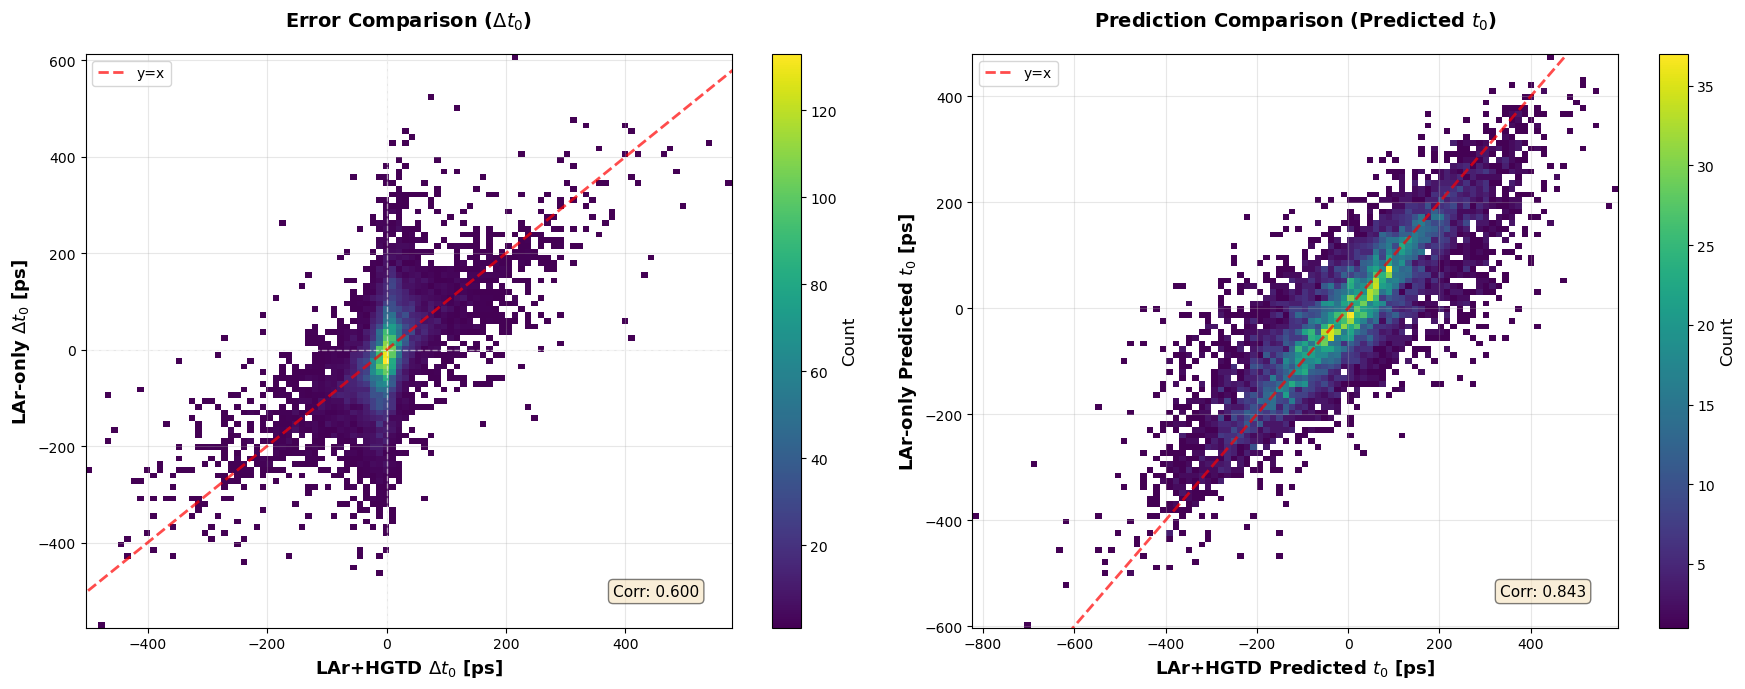


📊 Comparison Summary
Model 1: LAr+HGTD (hgtd_multi_input_dnn_with_jets_tracks)
  Mean Error: -0.4946 ps
  Std Error:  73.4237 ps

Model 2: LAr-only (test_1209_LAr)
  Mean Error: -7.7407 ps
  Std Error:  106.6567 ps

Error Correlation: 0.6001
Prediction Correlation: 0.8429
Total Samples: 8876


In [3]:
# Run verification
verify_identical_ytrue('hgtd_multi_input_dnn_with_jets_tracks', 'test_1209_LAr')

# Example 1: View first 10 predictions (default)
# df = view_predictions('test_1209_LAr_1e2', n=20)

# Example 3: View multiple models
for model in ['hgtd_multi_input_dnn_with_jets_tracks', 'test_1209_LAr']:
    view_predictions(model, n=5)
    print('\n' + '='*80 + '\n')

# Run the comparison
compare_model_errors_2d('hgtd_multi_input_dnn_with_jets_tracks', 'test_1209_LAr',
                        model1_label='LAr+HGTD', model2_label='LAr-only')

✓ Size check: Model1=8876, Model2=8876 → PASS
✓ Values identical (exact): PASS ✅
✓ Event numbers match: PASS ✅
✓ File indices match: PASS ✅
📂 Loading: ../models/hgtd_only_dnn/predictions.npz

📊 Summary Statistics for hgtd_only_dnn
Total samples: 8876
Format: Legacy (no event metadata)

Error Statistics:
  Mean Error:   2.033126
  Std Error:    113.676910
  Min Error:    -725.779907
  Max Error:    734.487915
  Median Error: 1.447499

📋 First 5 Predictions:


,Index,y_true,y_pred,error
0,0,-17.719139,-133.913605,-116.194466
1,1,-6.463560,-305.976562,-299.513000
2,2,255.248718,258.144897,2.896179
3,3,154.292496,140.001068,-14.291428
4,4,338.219238,317.187500,-21.031738




📂 Loading: ../models/test_1209_LAr/predictions.npz

📊 Summary Statistics for test_1209_LAr
Total samples: 8876
Format: New (with event metadata)
Unique files: 50

Error Statistics:
  Mean Error:   -7.740700
  Std Error:    106.656746
  Min Error:    -576.330139
  Max Error:    613.541260
  Median Error: -8.863730

📋 First 5 Predictions:


,Index,Event_Number,File_Index,y_true,y_pred,error
0,0,43170,34,-142.325104,-29.208302,113.116806
1,1,111671,9,-202.486069,-163.030869,39.455200
2,2,106679,44,-62.909557,-99.896729,-36.987171
3,3,99596,19,-52.310635,-39.674431,12.636204
4,4,92459,23,-50.675278,-46.020275,4.655003


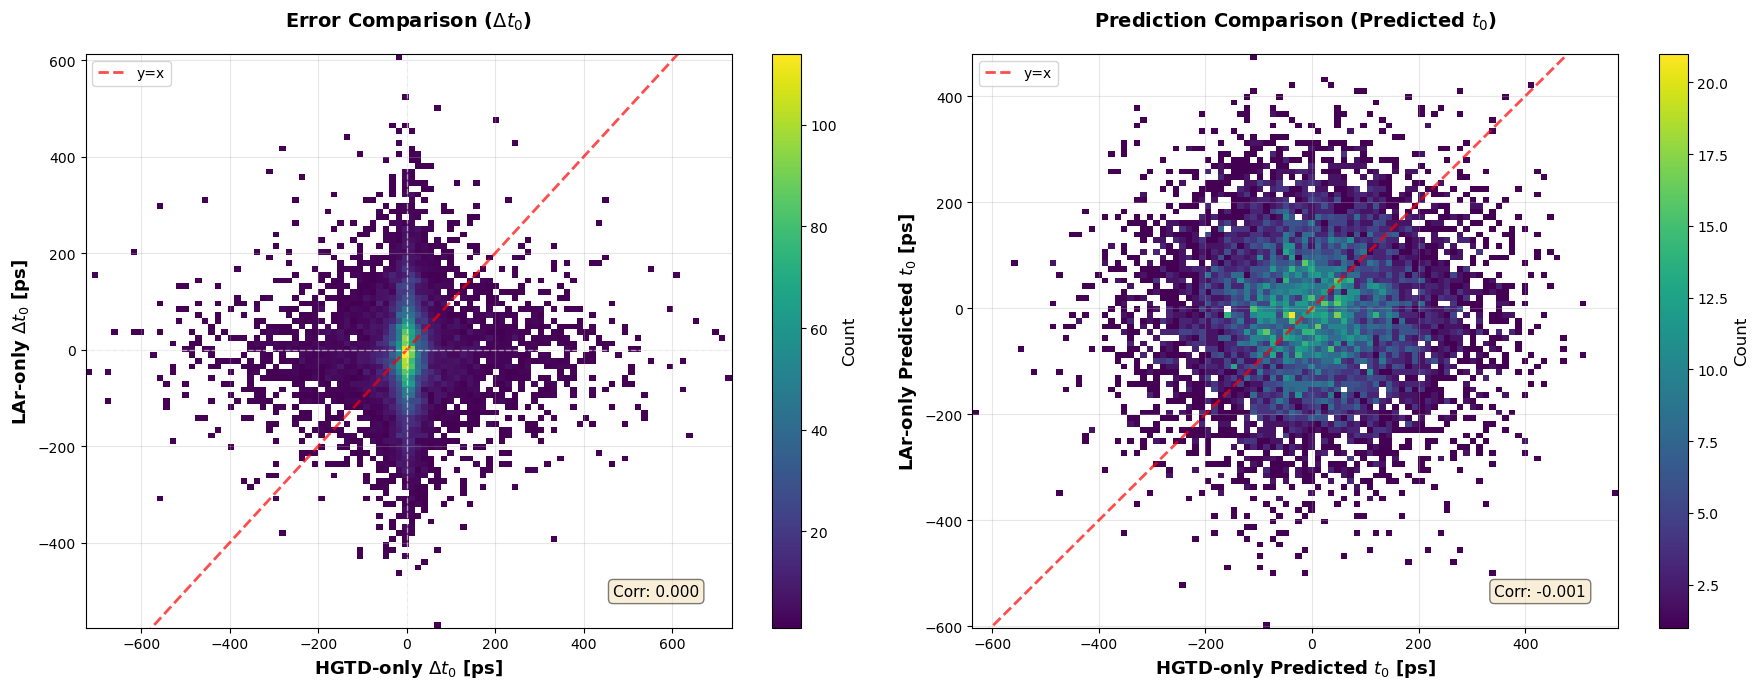


📊 Comparison Summary
Model 1: HGTD-only (hgtd_only_dnn)
  Mean Error: 2.0331 ps
  Std Error:  113.6769 ps

Model 2: LAr-only (test_1209_LAr)
  Mean Error: -7.7407 ps
  Std Error:  106.6567 ps

Error Correlation: 0.0003
Prediction Correlation: -0.0005
Total Samples: 8876


In [4]:
# Run verification
verify_identical_ytrue('hgtd_only_dnn_test', 'test_1209_LAr')

# Example 1: View first 10 predictions (default)
# df = view_predictions('test_1209_LAr_1e2', n=20)

# Example 3: View multiple models
for model in ['hgtd_only_dnn', 'test_1209_LAr']:
    view_predictions(model, n=5)
    print('\n' + '='*80 + '\n')

# Run the comparison
compare_model_errors_2d('hgtd_only_dnn', 'test_1209_LAr',
                        model1_label='HGTD-only', model2_label='LAr-only')

✓ Size check: Model1=8876, Model2=8876 → PASS
✓ Values identical (exact): PASS ✅
✓ Event numbers match: PASS ✅
✓ File indices match: PASS ✅
📂 Loading: ../models/hgtd_multi_input_dnn_with_jets_tracks/predictions.npz

📊 Summary Statistics for hgtd_multi_input_dnn_with_jets_tracks
Total samples: 8876
Format: New (with event metadata)
Unique files: 50

Error Statistics:
  Mean Error:   -0.494620
  Std Error:    73.423676
  Min Error:    -503.848877
  Max Error:    577.704468
  Median Error: -0.364219

📋 First 5 Predictions:


,Index,Event_Number,File_Index,y_true,y_pred,error
0,0,43170,34,-142.325104,-8.098275,134.226822
1,1,111671,9,-202.486069,-189.475845,13.010223
2,2,106679,44,-62.909557,-65.645531,-2.735973
3,3,99596,19,-52.310635,-56.101036,-3.790401
4,4,92459,23,-50.675278,-44.744549,5.930729




📂 Loading: ../models/hgtd_only_dnn_test/predictions.npz

📊 Summary Statistics for hgtd_only_dnn_test
Total samples: 8876
Format: New (with event metadata)
Unique files: 50

Error Statistics:
  Mean Error:   3.363130
  Std Error:    111.457291
  Min Error:    -756.876099
  Max Error:    764.965942
  Median Error: 3.237499

📋 First 5 Predictions:


,Index,Event_Number,File_Index,y_true,y_pred,error
0,0,43170,34,-142.325104,21.297588,163.622696
1,1,111671,9,-202.486069,-68.350868,134.135193
2,2,106679,44,-62.909557,-58.697521,4.212036
3,3,99596,19,-52.310635,-47.675930,4.634705
4,4,92459,23,-50.675278,-24.464439,26.210838


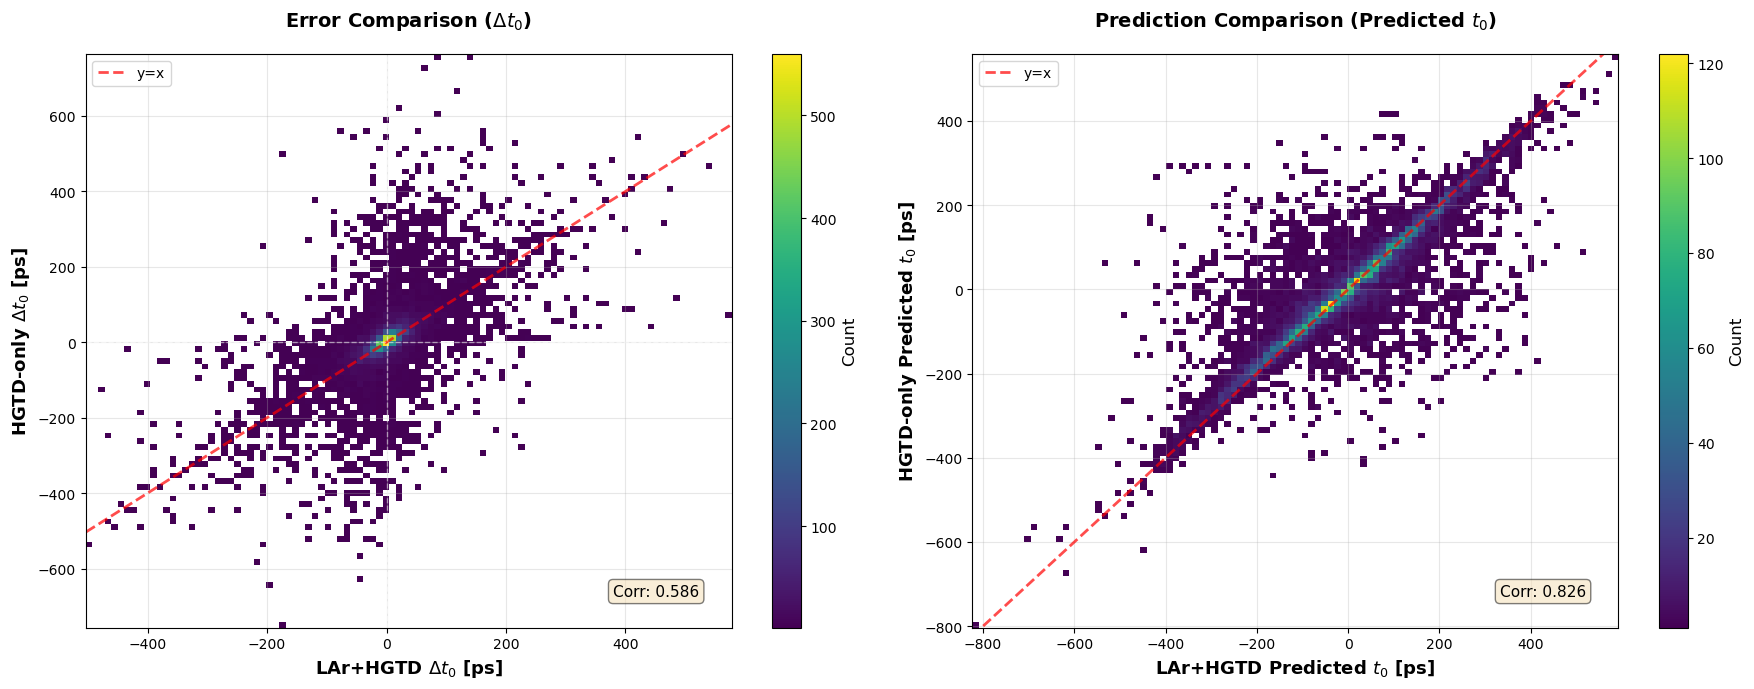


📊 Comparison Summary
Model 1: LAr+HGTD (hgtd_multi_input_dnn_with_jets_tracks)
  Mean Error: -0.4946 ps
  Std Error:  73.4237 ps

Model 2: HGTD-only (hgtd_only_dnn_test)
  Mean Error: 3.3631 ps
  Std Error:  111.4573 ps

Error Correlation: 0.5855
Prediction Correlation: 0.8260
Total Samples: 8876


In [5]:
# Run verification
verify_identical_ytrue('hgtd_multi_input_dnn_with_jets_tracks', 'hgtd_only_dnn_test')

# Example 1: View first 10 predictions (default)
# df = view_predictions('test_1209_LAr_1e2', n=20)

# Example 3: View multiple models
for model in ['hgtd_multi_input_dnn_with_jets_tracks', 'hgtd_only_dnn_test']:
    view_predictions(model, n=5)
    print('\n' + '='*80 + '\n')

# Run the comparison
compare_model_errors_2d('hgtd_multi_input_dnn_with_jets_tracks', 'hgtd_only_dnn_test',
                        model1_label='LAr+HGTD', model2_label='HGTD-only')

In [6]:
data_lar_hgtd = np.load('../models/hgtd_multi_input_dnn_with_jets_tracks/predictions.npz')
data_hgtd = np.load('../models/hgtd_only_dnn_test/predictions.npz')
data_lar = np.load('../models/test_1209_LAr/predictions.npz')

# Extract predictions and true values
y_true = data_lar_hgtd['y_true']  # Should be same for all models
y_pred_lar_hgtd = data_lar_hgtd['y_pred']
y_pred_hgtd = data_hgtd['y_pred']
y_pred_lar = data_lar['y_pred']

# Extract event metadata if available
has_metadata = 'event_numbers' in data_lar_hgtd and 'file_indices' in data_lar_hgtd

# Create DataFrame
df_data = {
    'Index': range(len(y_true)),
}

# Add event metadata if available
if has_metadata:
    df_data['Event_Num'] = data_lar_hgtd['event_numbers']
    df_data['File_Num'] = data_lar_hgtd['file_indices']

# Add predictions and true values
df_data.update({
    'True t₀ [ps]': y_true,
    'LAr+HGTD [ps]': y_pred_lar_hgtd,
    'HGTD-only [ps]': y_pred_hgtd,
    'LAr-only [ps]': y_pred_lar
})

df = pd.DataFrame(df_data)

# Add error columns
df['Error (LAr+HGTD)'] = y_pred_lar_hgtd - y_true
df['Error (HGTD-only)'] = y_pred_hgtd - y_true
df['Error (LAr-only)'] = y_pred_lar - y_true

print("📋 First 20 Events: True Values and Model Predictions")
print("="*120)
if has_metadata:
    print("✓ Event metadata available (Event_Num, File_Num)")
else:
    print("⚠️  No event metadata available in predictions file")
print("="*120)
display(df.head(20))

# Print summary statistics
print("\n📊 Summary Statistics")
print("="*120)
print(f"{'Model':<20} {'Mean Error [ps]':<20} {'Std Error [ps]':<20} {'RMSE [ps]':<20}")
print("-"*120)

for model_name, errors in [
    ('LAr+HGTD', df['Error (LAr+HGTD)']),
    ('HGTD-only', df['Error (HGTD-only)']),
    ('LAr-only', df['Error (LAr-only)'])
]:
    mean_err = errors.mean()
    std_err = errors.std()
    rmse = np.sqrt((errors**2).mean())
    print(f"{model_name:<20} {mean_err:<20.4f} {std_err:<20.4f} {rmse:<20.4f}")

if has_metadata:
    print(f"\n📊 Dataset Information")
    print("="*80)
    print(f"Total events: {len(df)}")
    print(f"Unique file indices: {df['File_Num'].nunique()}")
    print(f"File index range: {df['File_Num'].min()} - {df['File_Num'].max()}")

📋 First 20 Events: True Values and Model Predictions
✓ Event metadata available (Event_Num, File_Num)


,Index,Event_Num,File_Num,True t₀ [ps],LAr+HGTD [ps],HGTD-only [ps],LAr-only [ps],Error (LAr+HGTD),Error (HGTD-only),Error (LAr-only)
0,0,43170,34,-142.325104,-8.098275,21.297588,-29.208302,134.226822,163.622696,113.116806
1,1,111671,9,-202.486069,-189.475845,-68.350868,-163.030869,13.010223,134.135193,39.455200
2,2,106679,44,-62.909557,-65.645531,-58.697521,-99.896729,-2.735973,4.212036,-36.987171
3,3,99596,19,-52.310635,-56.101036,-47.675930,-39.674431,-3.790401,4.634705,12.636204
4,4,92459,23,-50.675278,-44.744549,-24.464439,-46.020275,5.930729,26.210838,4.655003
5,5,14180,8,283.860779,277.135284,262.404419,79.551727,-6.725494,-21.456360,-204.309052
6,6,19013,27,204.669083,64.563248,203.455536,-51.861591,-140.105835,-1.213547,-256.530670
7,7,33315,25,-344.895966,-293.616547,-314.226807,-122.795555,51.279419,30.669159,222.100403
8,8,183330,4,102.705460,36.486115,108.100983,-2.798299,-66.219345,5.395523,-105.503761
9,9,45869,41,112.385689,103.160324,106.150322,132.579086,-9.225365,-6.235367,20.193398



📊 Summary Statistics
Model                Mean Error [ps]      Std Error [ps]       RMSE [ps]           
------------------------------------------------------------------------------------------------------------------------
LAr+HGTD             -0.4946              73.4277              73.4253             
HGTD-only            3.3631               111.4636             111.5080            
LAr-only             -7.7407              106.6628             106.9373            

📊 Dataset Information
Total events: 8876
Unique file indices: 50
File index range: 0 - 49


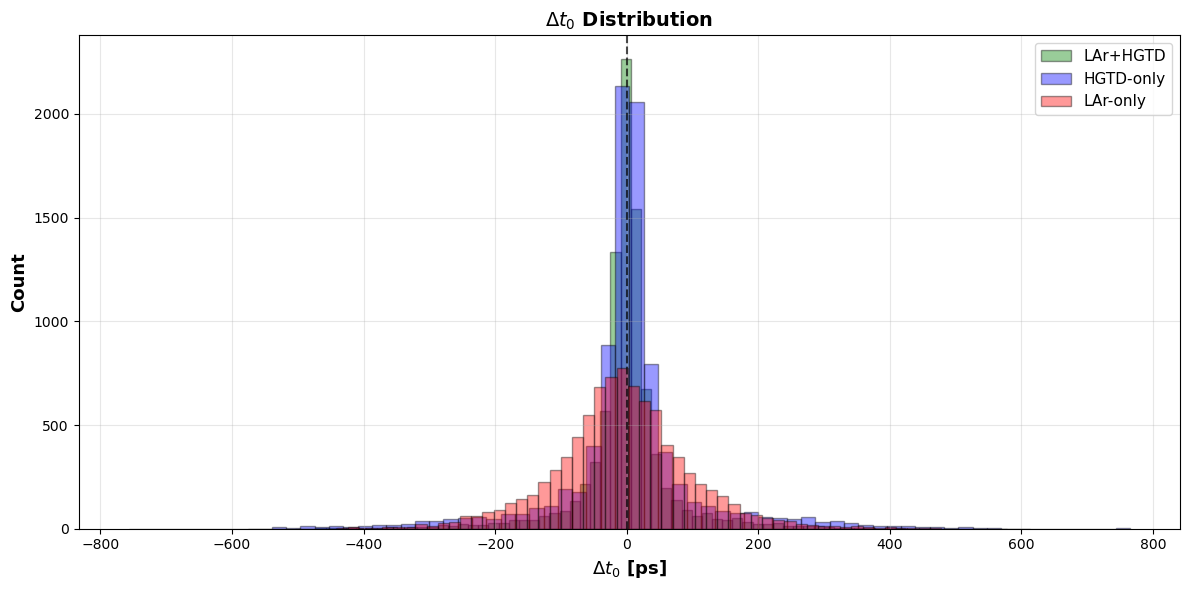


📊 Comparison: All Three Models
Model           Mean [ps]       Std [ps]        RMSE [ps]      
--------------------------------------------------------------------------------
LAr+HGTD               -0.4946        73.4277        73.4253
HGTD-only               3.3631       111.4636       111.5080
LAr-only               -7.7407       106.6628       106.9373


In [7]:
plt.figure(figsize=(12, 6))

# Plot all three error distributions
plt.hist(df['Error (LAr+HGTD)'], bins=70, alpha=0.4, label='LAr+HGTD', color='green', edgecolor='black')
plt.hist(df['Error (HGTD-only)'], bins=70, alpha=0.4, label='HGTD-only', color='blue', edgecolor='black')
plt.hist(df['Error (LAr-only)'], bins=70, alpha=0.4, label='LAr-only', color='red', edgecolor='black')

plt.xlabel('$\\Delta t_0$ [ps]', fontsize=13, fontweight='bold')
plt.ylabel('Count', fontsize=13, fontweight='bold')
plt.title('$\\Delta t_0$ Distribution', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.tight_layout()
plt.show()

# Print comparison statistics
print("\n📊 Comparison: All Three Models")
print("="*80)
print(f"{'Model':<15} {'Mean [ps]':<15} {'Std [ps]':<15} {'RMSE [ps]':<15}")
print("-"*80)
print(f"{'LAr+HGTD':<15} {df['Error (LAr+HGTD)'].mean():>14.4f} {df['Error (LAr+HGTD)'].std():>14.4f} {np.sqrt((df['Error (LAr+HGTD)']**2).mean()):>14.4f}")
print(f"{'HGTD-only':<15} {df['Error (HGTD-only)'].mean():>14.4f} {df['Error (HGTD-only)'].std():>14.4f} {np.sqrt((df['Error (HGTD-only)']**2).mean()):>14.4f}")
print(f"{'LAr-only':<15} {df['Error (LAr-only)'].mean():>14.4f} {df['Error (LAr-only)'].std():>14.4f} {np.sqrt((df['Error (LAr-only)']**2).mean()):>14.4f}")

In [12]:
# Filter events based on model comparison
comparison = 'better'  # Change to 'better' or 'worse'

# Calculate which model performs better for each event
df['LAr+HGTD_abs_error'] = np.abs(df['Error (LAr+HGTD)'])
df['HGTD-only_abs_error'] = np.abs(df['Error (HGTD-only)'])

if comparison == 'better':
    # LAr+HGTD is better than HGTD-only (smaller absolute error)
    filtered_df = df[df['LAr+HGTD_abs_error'] < df['HGTD-only_abs_error']].copy()
    title = "LAr+HGTD performs BETTER than HGTD-only"
else:
    # LAr+HGTD is worse than HGTD-only (larger absolute error)
    filtered_df = df[df['LAr+HGTD_abs_error'] > df['HGTD-only_abs_error']].copy()
    title = "LAr+HGTD performs WORSE than HGTD-only"

print(f"📋 Events where {title}")
print(f"{'='*120}")
print(f"Found {len(filtered_df)} events out of {len(df)} total ({100*len(filtered_df)/len(df):.2f}%)")
print(f"{'='*120}\n")

# Add improvement/degradation column
filtered_df['Improvement'] = filtered_df['HGTD-only_abs_error'] - filtered_df['LAr+HGTD_abs_error']

# Sort by improvement (positive = better, negative = worse)
filtered_df = filtered_df.sort_values('Improvement', ascending=False)

# Display results - include metadata if available
display_cols = ['Index']
if has_metadata:
    display_cols.extend(['Event_Num', 'File_Num'])
display_cols.extend(['True t₀ [ps]', 'LAr+HGTD [ps]', 'HGTD-only [ps]',
                    'Error (LAr+HGTD)', 'Error (HGTD-only)', 'Improvement'])

display(filtered_df[display_cols])

# Print statistics for filtered events
print(f"\n📊 Statistics for filtered events")
print(f"{'='*80}")
print(f"Average improvement: {filtered_df['Improvement'].mean():.4f} ps")
print(f"Max improvement: {filtered_df['Improvement'].max():.4f} ps")
print(f"Min improvement: {filtered_df['Improvement'].min():.4f} ps")
print(f"\n{'Model':<15} {'Mean Error [ps]':<20} {'Std Error [ps]':<20} {'RMSE [ps]':<15}")
print("-"*80)
for model_name in ['LAr+HGTD', 'HGTD-only']:
    errors = filtered_df[f'Error ({model_name})']
    print(f"{model_name:<15} {errors.mean():>19.4f} {errors.std():>19.4f} {np.sqrt((errors**2).mean()):>14.4f}")

# Print top 20 events with biggest improvement/degradation
print(f"\n📊 Top 20 Events (Sorted by {'Improvement' if comparison == 'better' else 'Degradation'})")
print(f"{'='*80}")
top_events_cols = ['Index']
if has_metadata:
    top_events_cols.extend(['Event_Num', 'File_Num'])
top_events_cols.extend(['True t₀ [ps]', 'HGTD-only [ps]', 'LAr+HGTD [ps]', 'Improvement'])
display(filtered_df[top_events_cols].head(20))

📋 Events where LAr+HGTD performs BETTER than HGTD-only
Found 5435 events out of 8876 total (61.23%)



,Index,Event_Num,File_Num,True t₀ [ps],LAr+HGTD [ps],HGTD-only [ps],Error (LAr+HGTD),Error (HGTD-only),Improvement
6121,6121,145440,39,-504.972015,-421.909363,259.765015,83.062653,764.737061,681.674438
4375,4375,151576,14,-432.532837,-368.444244,294.715363,64.088593,727.248169,663.159546
599,599,107046,44,-470.200897,-328.817780,294.765045,141.383118,764.965942,623.582825
3956,3956,122655,19,-451.687286,-430.301971,167.948395,21.385315,619.635681,598.250366
8309,8309,147756,6,582.451843,409.342346,-174.424255,-173.109497,-756.876099,583.766602
...,...,...,...,...,...,...,...,...,...
6531,6531,124075,20,-31.198639,-13.746289,-13.725716,17.452351,17.472923,0.020573
1843,1843,18043,27,218.712753,209.776596,209.760773,-8.936157,-8.951981,0.015823
202,202,62971,15,-115.609619,-121.352257,-109.855827,-5.742638,5.753792,0.011154
3928,3928,184977,4,109.499855,140.228027,78.761208,30.728172,-30.738647,0.010475



📊 Statistics for filtered events
Average improvement: 50.9498 ps
Max improvement: 681.6744 ps
Min improvement: 0.0028 ps

Model           Mean Error [ps]      Std Error [ps]       RMSE [ps]      
--------------------------------------------------------------------------------
LAr+HGTD                     0.4379             60.8266        60.8227
HGTD-only                    5.6297            134.8459       134.9511

📊 Top 20 Events (Sorted by Improvement)


,Index,Event_Num,File_Num,True t₀ [ps],HGTD-only [ps],LAr+HGTD [ps],Improvement
6121,6121,145440,39,-504.972015,259.765015,-421.909363,681.674438
4375,4375,151576,14,-432.532837,294.715363,-368.444244,663.159546
599,599,107046,44,-470.200897,294.765045,-328.817780,623.582825
3956,3956,122655,19,-451.687286,167.948395,-430.301971,598.250366
8309,8309,147756,6,582.451843,-174.424255,409.342346,583.766602
7402,7402,68077,17,-424.420685,160.728226,-429.601837,579.967773
506,506,106948,44,426.354340,-195.950439,377.848877,573.799316
7425,7425,112375,12,-527.949951,144.563065,-409.562042,554.125122
4949,4949,149052,6,-260.541779,286.835327,-261.950836,545.968018
5432,5432,34098,25,329.402008,-202.333908,321.202789,523.536682


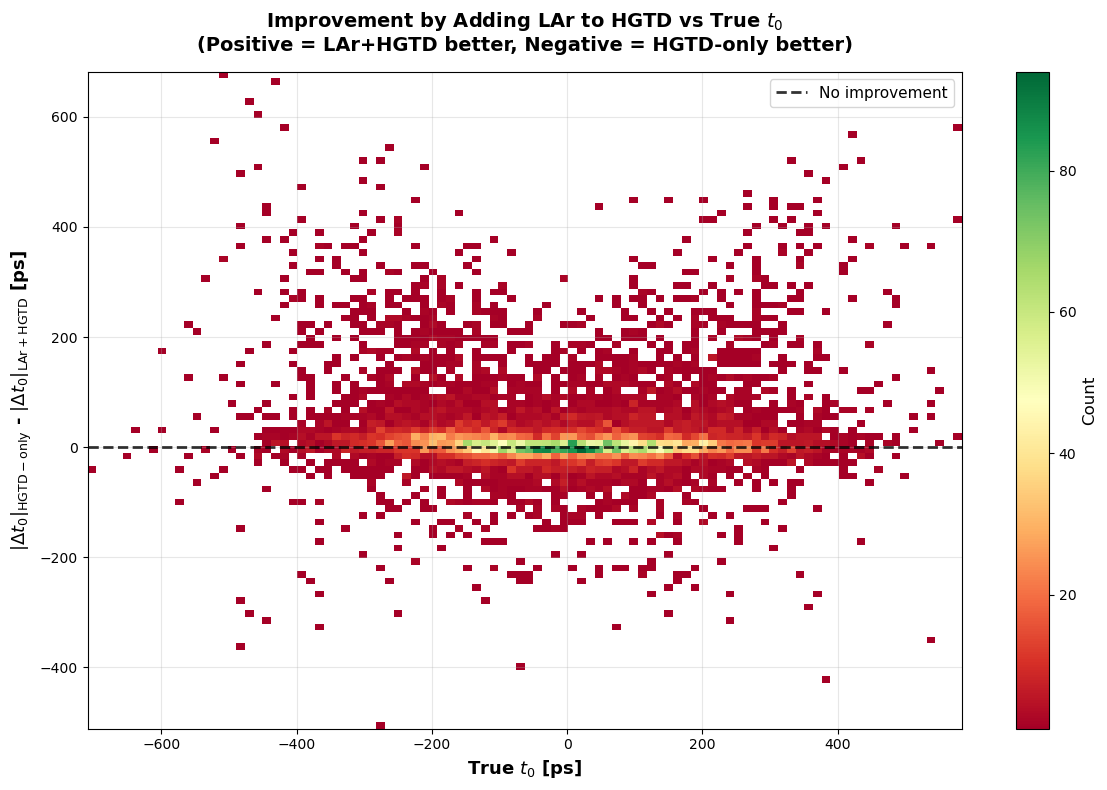

📊 Overall Improvement Statistics
Mean improvement: 21.6658 ps
Median improvement: 4.5269 ps
Std improvement: 79.5134 ps
Events where LAr+HGTD better: 5435 (61.23%)
Events where HGTD-only better: 3441 (38.77%)


In [9]:
# 2D Histogram: Truth time vs Improvement
plt.figure(figsize=(12, 8))

# Calculate improvement: |HGTD-only error| - |LAr+HGTD error|
# Positive values mean LAr+HGTD is better
improvement = df['HGTD-only_abs_error'] - df['LAr+HGTD_abs_error']

h = plt.hist2d(df['True t₀ [ps]'], improvement, 
               bins=100, cmap='RdYlGn', cmin=1)

cbar = plt.colorbar(h[3])
cbar.set_label('Count', fontsize=12)

plt.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.8, label='No improvement')
plt.xlabel('True $t_0$ [ps]', fontsize=13, fontweight='bold')
plt.ylabel('$|\\Delta t_0|_{\\mathrm{HGTD-only}}$ - $|\\Delta t_0|_{\\mathrm{LAr+HGTD}}$ [ps]', fontsize=13, fontweight='bold')
plt.title('Improvement by Adding LAr to HGTD vs True $t_0$\n(Positive = LAr+HGTD better, Negative = HGTD-only better)', 
          fontsize=14, fontweight='bold', pad=15)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"📊 Overall Improvement Statistics")
print(f"{'='*60}")
print(f"Mean improvement: {improvement.mean():.4f} ps")
print(f"Median improvement: {improvement.median():.4f} ps")
print(f"Std improvement: {improvement.std():.4f} ps")
print(f"Events where LAr+HGTD better: {(improvement > 0).sum()} ({100*(improvement > 0).sum()/len(improvement):.2f}%)")
print(f"Events where HGTD-only better: {(improvement < 0).sum()} ({100*(improvement < 0).sum()/len(improvement):.2f}%)")

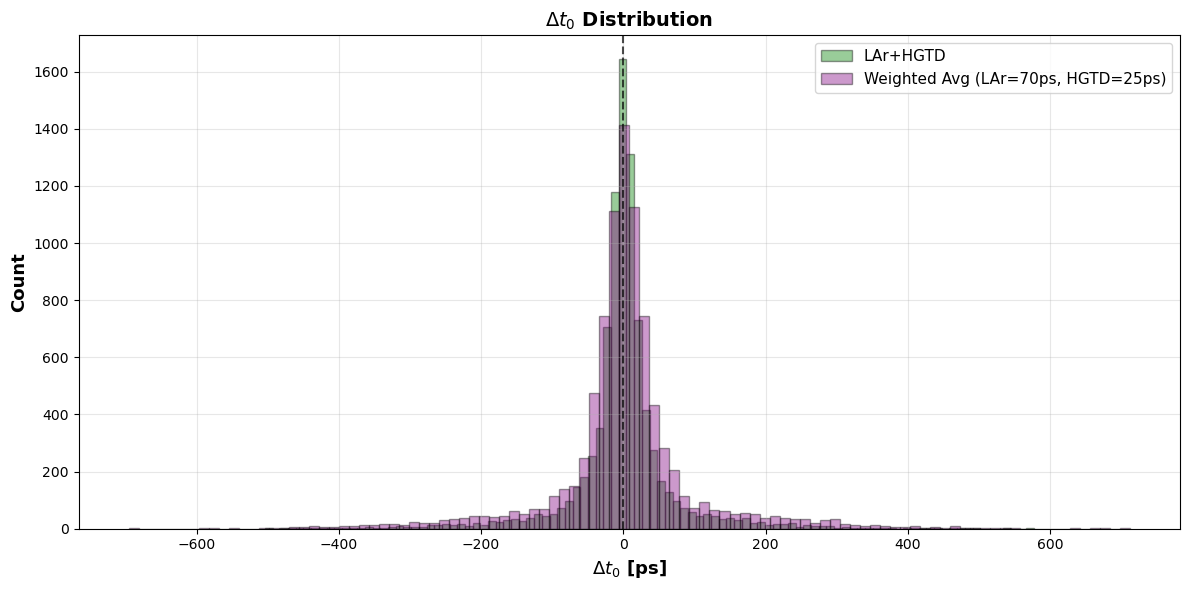


📊 Comparison: All Four Models
Model                     Mean [ps]       Std [ps]        RMSE [ps]      
--------------------------------------------------------------------------------
LAr+HGTD                         -0.4946        73.4278        73.4253
HGTD-only                         3.3631       111.4636       111.5080
LAr-only                         -7.7407       106.6628       106.9373
Weighted Avg                      2.1070       104.0217       104.0372


In [10]:
x = 70  # LAr time resolution in ps
y = 25  # HGTD time resolution in ps

weight_lar = 1 / (x**2)
weight_hgtd = 1 / (y**2)
weight_sum = weight_lar + weight_hgtd

df['Weighted Average [ps]'] = (y_pred_lar * weight_lar + y_pred_hgtd * weight_hgtd) / weight_sum
df['Error (Weighted Avg)'] = df['Weighted Average [ps]'] - y_true

plt.figure(figsize=(12, 6))

plt.hist(df['Error (LAr+HGTD)'], bins=100, alpha=0.4, label='LAr+HGTD', color='green', edgecolor='black')
plt.hist(df['Error (Weighted Avg)'], bins=100, alpha=0.4, label=f'Weighted Avg (LAr={x}ps, HGTD={y}ps)', color='purple', edgecolor='black')

plt.xlabel('$\\Delta t_0$ [ps]', fontsize=13, fontweight='bold')
plt.ylabel('Count', fontsize=13, fontweight='bold')
plt.title('$\\Delta t_0$ Distribution', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.tight_layout()
plt.show()

print("\n📊 Comparison: All Four Models")
print("="*80)
print(f"{'Model':<25} {'Mean [ps]':<15} {'Std [ps]':<15} {'RMSE [ps]':<15}")
print("-"*80)
print(f"{'LAr+HGTD':<25} {df['Error (LAr+HGTD)'].mean():>14.4f} {df['Error (LAr+HGTD)'].std():>14.4f} {np.sqrt((df['Error (LAr+HGTD)']**2).mean()):>14.4f}")
print(f"{'HGTD-only':<25} {df['Error (HGTD-only)'].mean():>14.4f} {df['Error (HGTD-only)'].std():>14.4f} {np.sqrt((df['Error (HGTD-only)']**2).mean()):>14.4f}")
print(f"{'LAr-only':<25} {df['Error (LAr-only)'].mean():>14.4f} {df['Error (LAr-only)'].std():>14.4f} {np.sqrt((df['Error (LAr-only)']**2).mean()):>14.4f}")
print(f"{'Weighted Avg':<25} {df['Error (Weighted Avg)'].mean():>14.4f} {df['Error (Weighted Avg)'].std():>14.4f} {np.sqrt((df['Error (Weighted Avg)']**2).mean()):>14.4f}")

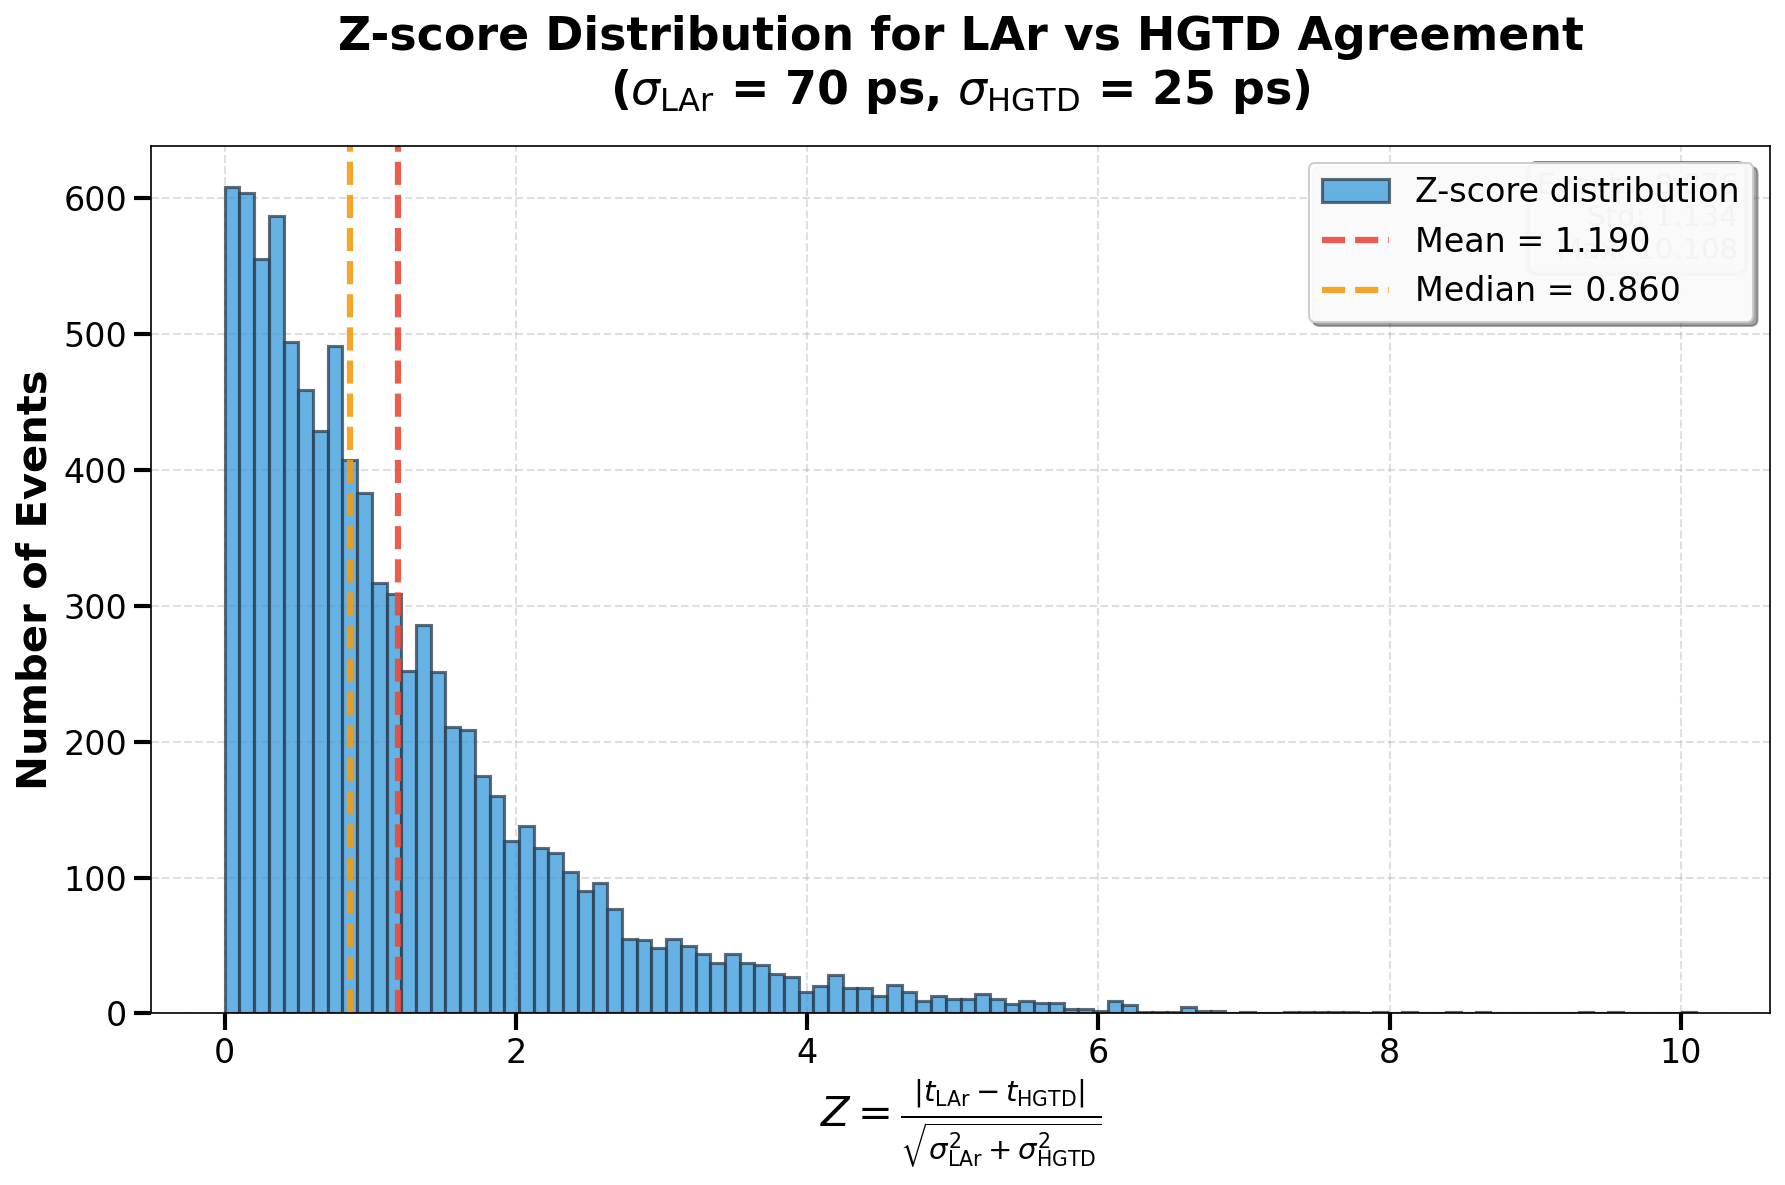

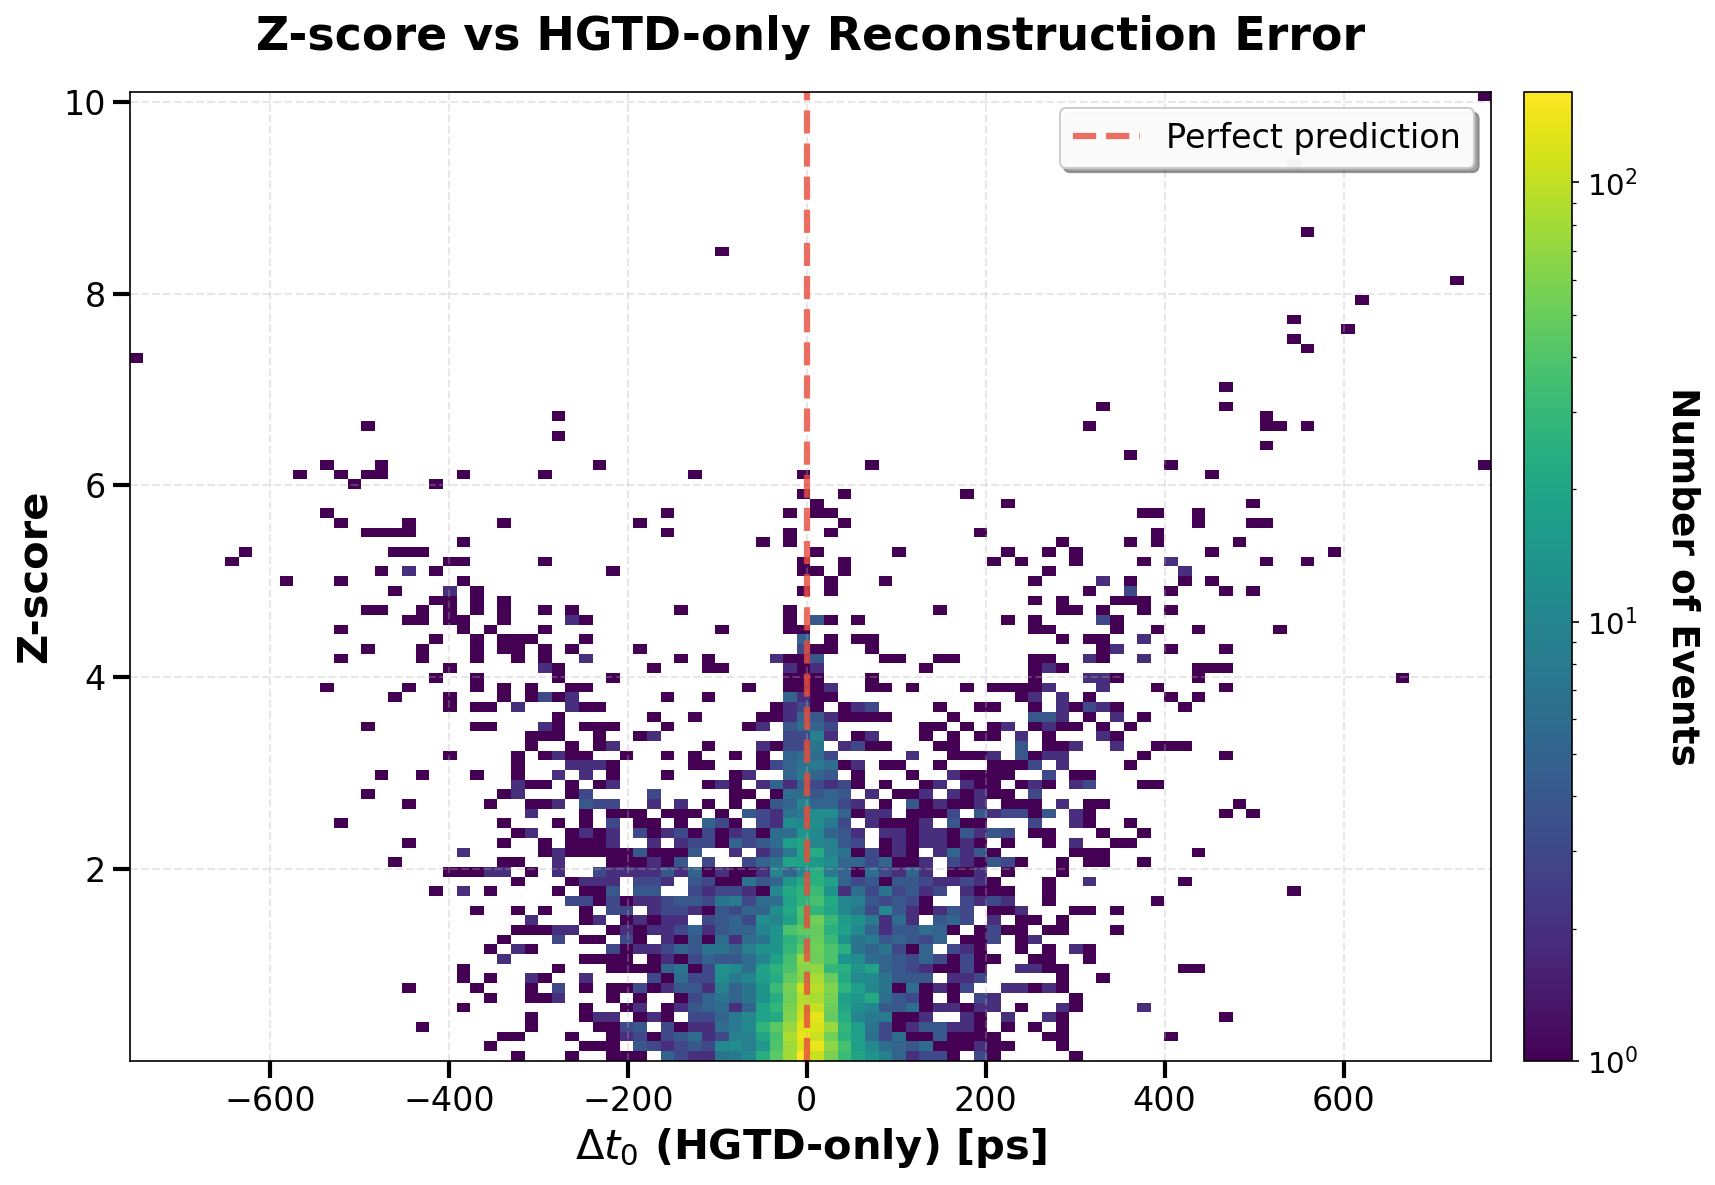

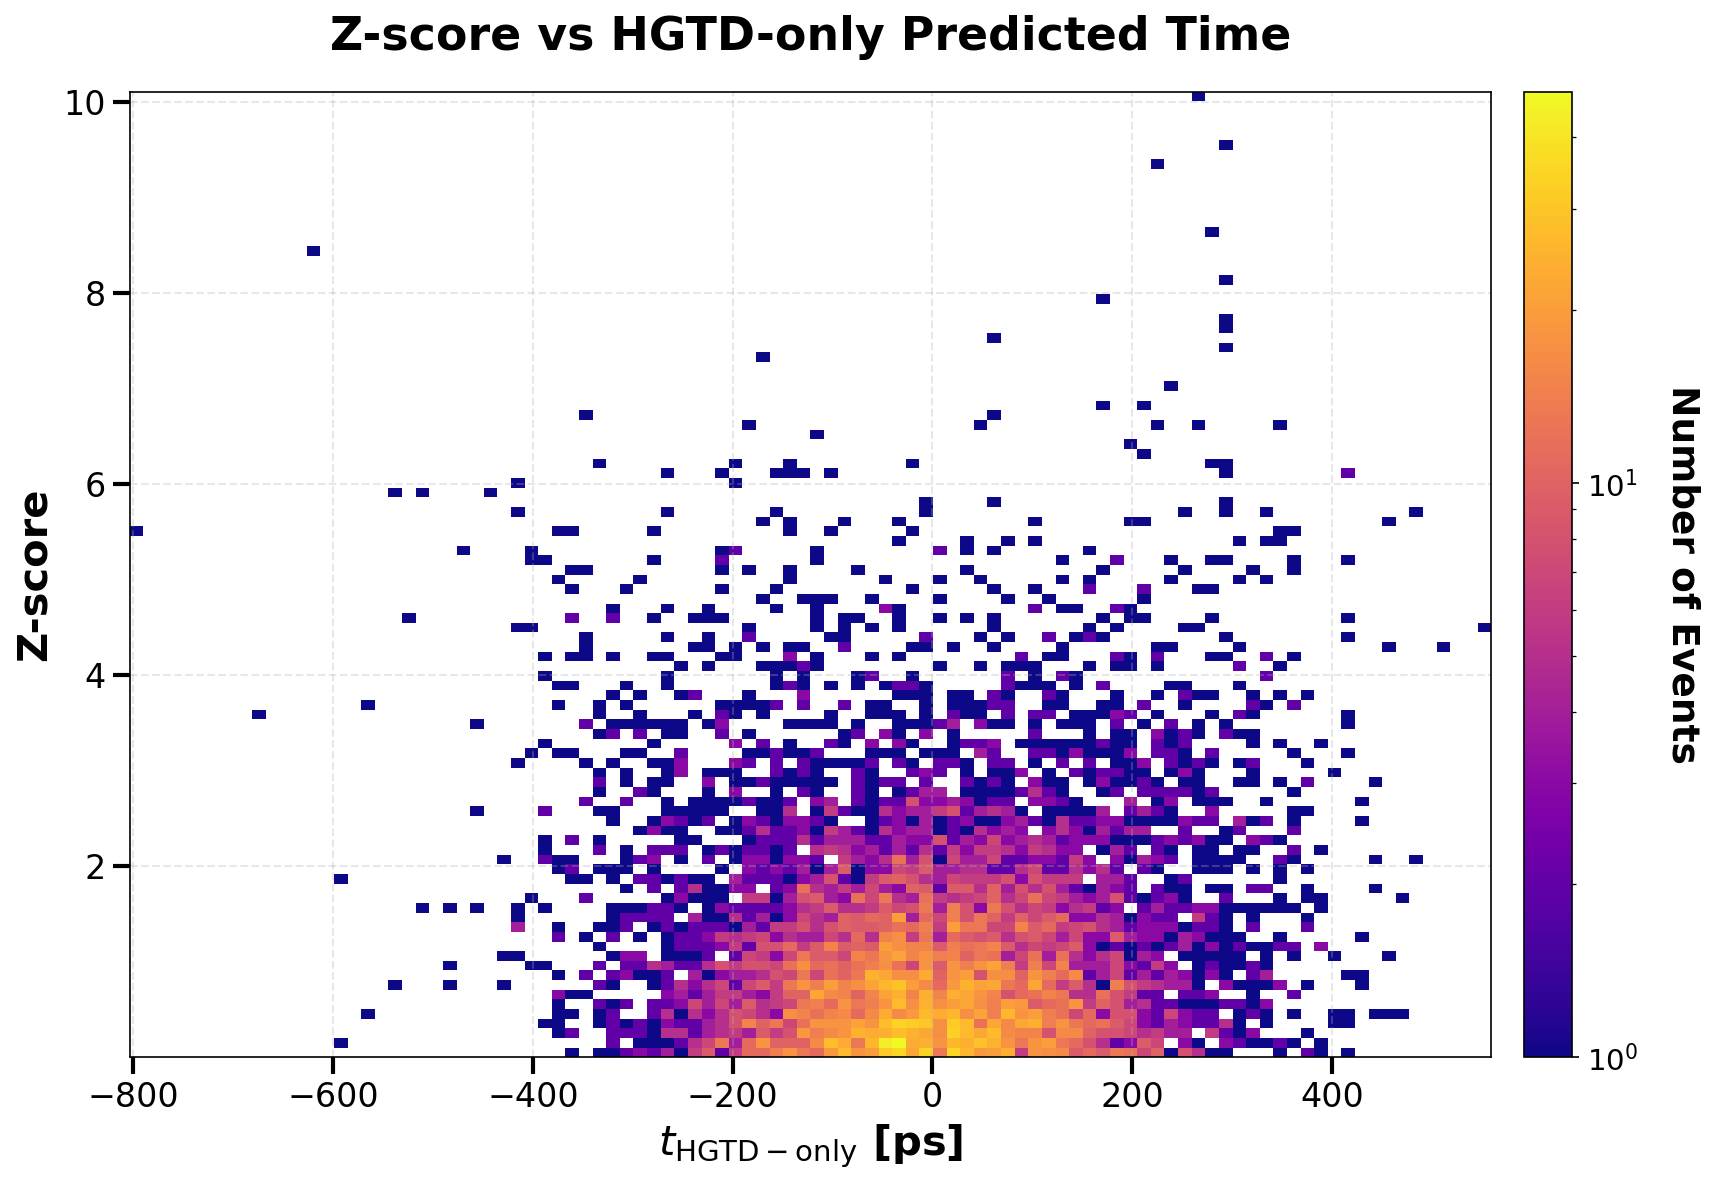

📊 Z-score Statistics
Mean Z-score:        1.1902
Median Z-score:      0.8600
Std Z-score:         1.1335
Max Z-score:         10.1076
Min Z-score:         0.0001

Events with Z > 1:   3892 (43.85%)
Events with Z > 2:   1591 (17.92%)
Events with Z > 3:   670 (7.55%)

🔝 Top 10 Events with HIGHEST Z-score


,Index,Event_Num,File_Num,True t₀ [ps],LAr-only [ps],HGTD-only [ps],Error (LAr-only),Error (HGTD-only),Z_score
6121,6121,145440,39,-504.972015,-491.538300,259.765015,13.433716,764.737061,10.107626
4516,4516,182969,31,-217.889175,-419.743408,286.897156,-201.854233,504.786316,9.506758
6328,6328,194735,40,-308.275299,-467.146698,230.801270,-158.871399,539.076538,9.389812
1994,1994,124797,36,-273.207275,-357.285004,283.918274,-84.077728,557.125549,8.626399
8597,8597,97679,30,-524.590576,3.462267,-622.652588,528.052856,-98.062012,8.423409
4375,4375,151576,14,-432.532837,-312.301483,294.715363,120.231354,727.248169,8.166474
3956,3956,122655,19,-451.687286,-425.487000,167.948395,26.200287,619.635681,7.983757
4949,4949,149052,6,-260.541779,-286.124390,286.835327,-25.582611,547.377075,7.708288
6249,6249,133196,18,-306.602570,-272.389954,296.034271,34.212616,602.636841,7.647270
23,23,126466,5,-483.953522,-494.857788,67.139542,-10.904266,551.093079,7.560806



🔻 Top 10 Events with LOWEST Z-score


,Index,Event_Num,File_Num,True t₀ [ps],LAr-only [ps],HGTD-only [ps],Error (LAr-only),Error (HGTD-only),Z_score
5061,5061,100696,19,-40.096848,-39.640606,-39.646061,0.456242,0.450787,0.000073
8760,8760,82010,16,230.977661,211.953964,211.969162,-19.023697,-19.008499,0.000204
2843,2843,193062,40,-74.501488,-73.022293,-73.052437,1.479195,1.449051,0.000406
5126,5126,122575,19,-195.140900,-186.008987,-186.047668,9.131912,9.093231,0.000520
3497,3497,38511,26,-136.660736,-80.229362,-80.271111,56.431374,56.389626,0.000562
1015,1015,17051,8,-165.915649,-144.307541,-144.363373,21.608109,21.552277,0.000751
3456,3456,99463,19,439.728882,411.546173,411.602753,-28.182709,-28.126129,0.000761
4380,4380,115811,12,-52.209896,-33.254807,-33.175816,18.955090,19.034081,0.001063
6538,6538,75837,45,-39.939400,-48.237591,-48.316662,-8.298191,-8.377262,0.001064
6219,6219,4521,9,277.022614,126.892090,127.007767,-150.130524,-150.014847,0.001556



📊 Summary of Extreme Z-score Events
Category             Mean Z-score    Mean |Error(LAr)|    Mean |Error(HGTD)|  
--------------------------------------------------------------------------------
Top 10 Highest               8.5121            120.3421            551.1779
Top 10 Lowest                0.0007             31.3697             31.3496


In [11]:
# Calculate Z-score: |t_LAr - t_HGTD| / sqrt(sigma_LAr^2 + sigma_HGTD^2)
sigma_lar = 70  # ps
sigma_hgtd = 25  # ps

df['Z_score'] = np.abs(y_pred_lar - y_pred_hgtd) / np.sqrt(sigma_lar**2 + sigma_hgtd**2)
df['HGTD_error'] = y_pred_hgtd - y_true

# ====================================================================
# Figure 1: Z-score Distribution (High Quality, Beautiful)
# ====================================================================
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

# Plot histogram with beautiful styling
n, bins, patches = ax.hist(df['Z_score'], bins=100, alpha=0.75, 
                           color='#3498db', edgecolor='#2c3e50', linewidth=1.5,
                           label='Z-score distribution')

# Add mean and median lines
mean_z = df['Z_score'].mean()
median_z = df['Z_score'].median()

ax.axvline(x=mean_z, color='#e74c3c', linestyle='--', linewidth=3, 
           label=f'Mean = {mean_z:.3f}', alpha=0.9)
ax.axvline(x=median_z, color='#f39c12', linestyle='--', linewidth=3,
           label=f'Median = {median_z:.3f}', alpha=0.9)

# Labels and title with larger fonts
ax.set_xlabel('$Z = \\frac{|t_{\\mathrm{LAr}} - t_{\\mathrm{HGTD}}|}{\\sqrt{\\sigma_{\\mathrm{LAr}}^2 + \\sigma_{\\mathrm{HGTD}}^2}}$', 
              fontsize=20, fontweight='bold')
ax.set_ylabel('Number of Events', fontsize=20, fontweight='bold')
ax.set_title(f'Z-score Distribution for LAr vs HGTD Agreement\n($\\sigma_{{\\mathrm{{LAr}}}}$ = {sigma_lar} ps, $\\sigma_{{\\mathrm{{HGTD}}}}$ = {sigma_hgtd} ps)', 
             fontsize=22, fontweight='bold', pad=20)

# Enhanced legend
ax.legend(fontsize=16, loc='upper right', frameon=True, shadow=True, 
          fancybox=True, framealpha=0.95)

# Grid styling
ax.grid(True, alpha=0.4, linestyle='--', linewidth=1)
ax.set_axisbelow(True)

# Tick parameters
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=8)
ax.tick_params(axis='both', which='minor', labelsize=14, width=1.5, length=5)

# Add statistics box
stats_text = f'Events: {len(df):,}\nStd: {df["Z_score"].std():.3f}\nMax: {df["Z_score"].max():.3f}'
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
        fontsize=14, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#34495e', linewidth=2))

plt.tight_layout()
plt.show()

# ====================================================================
# Figure 2: Z-score vs HGTD Error (2D Histogram)
# ====================================================================
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

h = ax.hist2d(df['HGTD_error'], df['Z_score'], bins=100, 
              cmap='viridis', cmin=1, norm=plt.matplotlib.colors.LogNorm())

# Colorbar
cbar = plt.colorbar(h[3], ax=ax, pad=0.02)
cbar.set_label('Number of Events', fontsize=18, fontweight='bold', rotation=270, labelpad=30)
cbar.ax.tick_params(labelsize=14)

# Perfect prediction line
ax.axvline(x=0, color='#e74c3c', linestyle='--', linewidth=3, 
           alpha=0.8, label='Perfect prediction')

# Labels and title
ax.set_xlabel('$\\Delta t_0$ (HGTD-only) [ps]', fontsize=20, fontweight='bold')
ax.set_ylabel('Z-score', fontsize=20, fontweight='bold')
ax.set_title('Z-score vs HGTD-only Reconstruction Error', 
             fontsize=22, fontweight='bold', pad=20)

# Legend
ax.legend(fontsize=16, loc='upper right', frameon=True, shadow=True, 
          fancybox=True, framealpha=0.95)

# Grid and ticks
ax.grid(True, alpha=0.3, linestyle='--', linewidth=1)
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=8)

plt.tight_layout()
plt.show()

# ====================================================================
# Figure 3: Z-score vs HGTD Prediction Value
# ====================================================================
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

h = ax.hist2d(y_pred_hgtd, df['Z_score'], bins=100, 
              cmap='plasma', cmin=1, norm=plt.matplotlib.colors.LogNorm())

# Colorbar
cbar = plt.colorbar(h[3], ax=ax, pad=0.02)
cbar.set_label('Number of Events', fontsize=18, fontweight='bold', rotation=270, labelpad=30)
cbar.ax.tick_params(labelsize=14)

# Labels and title
ax.set_xlabel('$t_{\\mathrm{HGTD-only}}$ [ps]', fontsize=20, fontweight='bold')
ax.set_ylabel('Z-score', fontsize=20, fontweight='bold')
ax.set_title('Z-score vs HGTD-only Predicted Time', 
             fontsize=22, fontweight='bold', pad=20)

# Grid and ticks
ax.grid(True, alpha=0.3, linestyle='--', linewidth=1)
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=8)

plt.tight_layout()
plt.show()

# ====================================================================
# Print Statistics
# ====================================================================
print("📊 Z-score Statistics")
print("="*60)
print(f"Mean Z-score:        {df['Z_score'].mean():.4f}")
print(f"Median Z-score:      {df['Z_score'].median():.4f}")
print(f"Std Z-score:         {df['Z_score'].std():.4f}")
print(f"Max Z-score:         {df['Z_score'].max():.4f}")
print(f"Min Z-score:         {df['Z_score'].min():.4f}")
print(f"\nEvents with Z > 1:   {(df['Z_score'] > 1).sum()} ({100*(df['Z_score'] > 1).sum()/len(df):.2f}%)")
print(f"Events with Z > 2:   {(df['Z_score'] > 2).sum()} ({100*(df['Z_score'] > 2).sum()/len(df):.2f}%)")
print(f"Events with Z > 3:   {(df['Z_score'] > 3).sum()} ({100*(df['Z_score'] > 3).sum()/len(df):.2f}%)")

# Top 10 highest Z-score events
print("\n" + "="*120)
print("🔝 Top 10 Events with HIGHEST Z-score")
print("="*120)
top_10_high = df.nlargest(10, 'Z_score')
display_cols = ['Index']
if has_metadata:
    display_cols.extend(['Event_Num', 'File_Num'])
display_cols.extend(['True t₀ [ps]', 'LAr-only [ps]', 'HGTD-only [ps]', 
                    'Error (LAr-only)', 'Error (HGTD-only)', 'Z_score'])
display(top_10_high[display_cols])

# Top 10 lowest Z-score events
print("\n" + "="*120)
print("🔻 Top 10 Events with LOWEST Z-score")
print("="*120)
top_10_low = df.nsmallest(10, 'Z_score')
display(top_10_low[display_cols])

# Summary statistics for these events
print("\n📊 Summary of Extreme Z-score Events")
print("="*80)
print(f"{'Category':<20} {'Mean Z-score':<15} {'Mean |Error(LAr)|':<20} {'Mean |Error(HGTD)|':<20}")
print("-"*80)
print(f"{'Top 10 Highest':<20} {top_10_high['Z_score'].mean():>14.4f} "
      f"{top_10_high['Error (LAr-only)'].abs().mean():>19.4f} "
      f"{top_10_high['Error (HGTD-only)'].abs().mean():>19.4f}")
print(f"{'Top 10 Lowest':<20} {top_10_low['Z_score'].mean():>14.4f} "
      f"{top_10_low['Error (LAr-only)'].abs().mean():>19.4f} "
      f"{top_10_low['Error (HGTD-only)'].abs().mean():>19.4f}")

📊 Applying Z-score cut: Z ≤ 2.0
Events before cut: 8876
Events after cut:  7285 (82.08%)
Events removed:    1591 (17.92%)


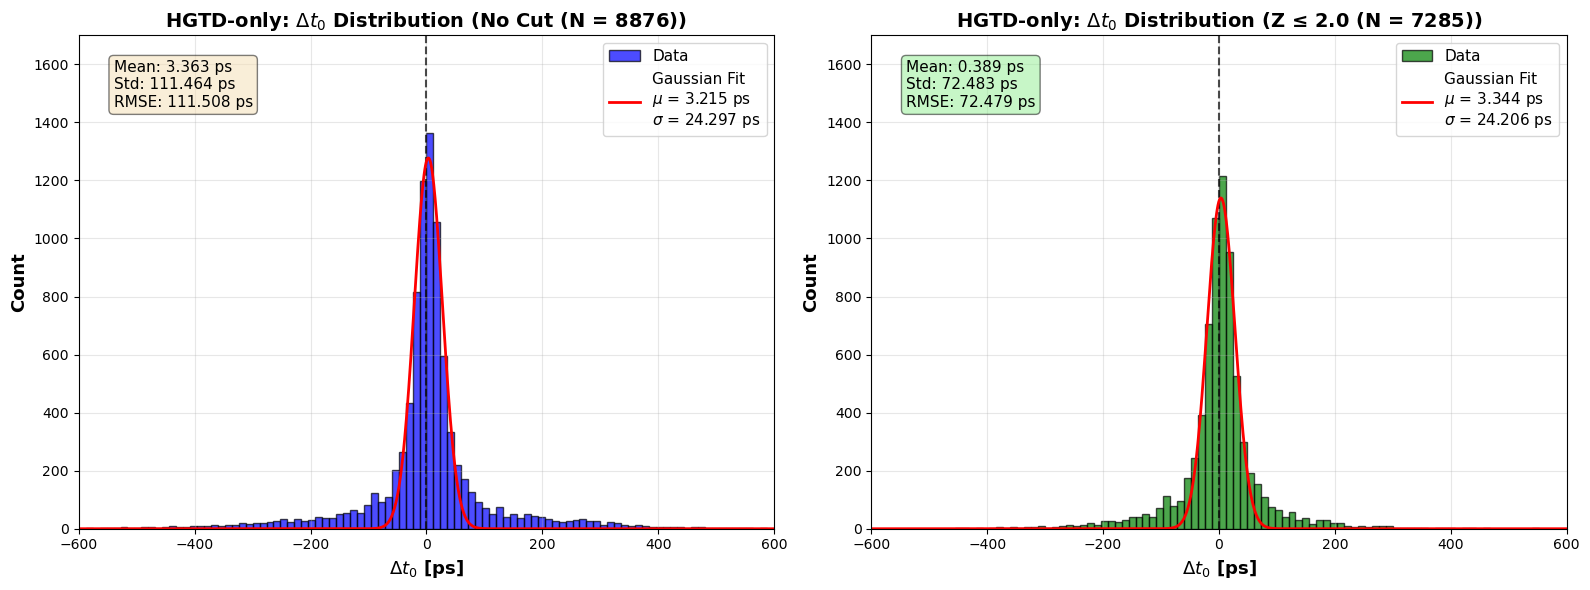


📊 HGTD-only Performance Comparison
Metric               No Cut               Z ≤ 2.0              Improvement         
--------------------------------------------------------------------------------
Mean [ps]                         3.3631              0.3889              2.9743
Std [ps]                        111.4573             72.4782             38.9790
RMSE [ps]                       111.5080             72.4793             39.0287

📊 HGTD-only Performance Comparison
Metric               No Cut               Z ≤ 2.0              Improvement         
--------------------------------------------------------------------------------
Mean [ps]                         3.3631              0.3889              2.9743
Std [ps]                        111.4573             72.4782             38.9790
RMSE [ps]                       111.5080             72.4793             39.0287

🔴 Top 10 Events with LARGEST |Δt₀| after Z-score cut (Z ≤ 2.0)


,Index,Event_Num,File_Num,True t₀ [ps],LAr-only [ps],HGTD-only [ps],Error (LAr-only),Error (HGTD-only),Abs_Error_HGTD,Z_score
5303,5303,102620,44,-554.563293,-144.193924,-13.700167,410.369385,540.863098,540.863098,1.755592
1492,1492,43162,34,-444.585205,-15.179907,20.418999,429.405304,465.004211,465.004211,0.478928
3081,3081,66081,48,429.742310,36.883183,-16.547621,-392.859131,-446.289917,446.289917,0.718829
1219,1219,80175,19,121.079079,-286.977112,-314.394470,-408.056183,-435.473541,435.473541,0.368858
1911,1911,132171,5,-386.919617,-27.425268,46.216290,359.494354,433.135895,433.135895,0.990733
4429,4429,8199,8,-456.561981,-105.632202,-32.060013,350.929779,424.501953,424.501953,0.989800
8054,8054,24318,35,-281.419495,4.145764,141.935944,285.565247,423.355438,423.355438,1.853754
960,960,75621,45,290.062500,10.454157,-124.045372,-279.608337,-414.107880,414.107880,1.809483
4423,4423,120019,36,-546.039307,-123.851639,-142.582993,422.187683,403.456299,403.456299,0.252001
3290,3290,36396,32,234.818100,-79.027870,-153.480133,-313.845978,-388.298218,388.298218,1.001640



📊 Analysis of Top 10 Worst Events (after cut)
Mean |Error|:           437.449 ps
Mean Z-score:           1.022
Mean True t₀:           -159.439 ps
Mean Predicted t₀:      -58.824 ps


In [21]:
from scipy.optimize import curve_fit

# Gaussian function
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean)**2) / (2 * sigma**2))

# Specify Z-score cut threshold
z_cut = 2.0  # Change this value as needed

# Apply Z-score cut
df_filtered = df[df['Z_score'] <= z_cut].copy()

print(f"📊 Applying Z-score cut: Z ≤ {z_cut}")
print("="*80)
print(f"Events before cut: {len(df)}")
print(f"Events after cut:  {len(df_filtered)} ({100*len(df_filtered)/len(df):.2f}%)")
print(f"Events removed:    {len(df) - len(df_filtered)} ({100*(len(df) - len(df_filtered))/len(df):.2f}%)")
print("="*80)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (data, title, color) in enumerate([
    (df['Error (HGTD-only)'], f'No Cut (N = {len(df)})', 'blue'),
    (df_filtered['Error (HGTD-only)'], f'Z ≤ {z_cut} (N = {len(df_filtered)})', 'green')
]):
    # Histogram
    n, bins, _ = axes[idx].hist(data, bins=100, alpha=0.7, color=color, edgecolor='black', label='Data', range=(-600, 600))
    axes[idx].axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Gaussian fit
    bin_centers = (bins[:-1] + bins[1:]) / 2
    popt, _ = curve_fit(gaussian, bin_centers, n, p0=[n.max(), data.mean(), data.std()])
    x_fit = np.linspace(bins[0], bins[-1], 1000)
    axes[idx].plot(x_fit, gaussian(x_fit, *popt), 'r-', linewidth=2, 
                   label=f'Gaussian Fit\n$\\mu$ = {popt[1]:.3f} ps\n$\\sigma$ = {abs(popt[2]):.3f} ps')
    
    # Labels and text
    axes[idx].set_xlabel('$\\Delta t_0$ [ps]', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Count', fontsize=13, fontweight='bold')
    axes[idx].set_title(f'HGTD-only: $\\Delta t_0$ Distribution ({title})', fontsize=14, fontweight='bold')
    axes[idx].set_xlim(-600, 600)
    axes[idx].set_ylim(0, 1700)
    axes[idx].legend(fontsize=11, loc='upper right')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].text(0.05, 0.95, f'Mean: {data.mean():.3f} ps\nStd: {data.std():.3f} ps\nRMSE: {np.sqrt((data**2).mean()):.3f} ps',
                   transform=axes[idx].transAxes, fontsize=11, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat' if idx==0 else 'lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()

# Print statistics
print(f"\n📊 HGTD-only Performance Comparison")
print("="*80)
print(f"{'Metric':<20} {'No Cut':<20} {'Z ≤ ' + str(z_cut):<20} {'Improvement':<20}")
print("-"*80)
for metric, func in [('Mean [ps]', np.mean), ('Std [ps]', np.std), ('RMSE [ps]', lambda x: np.sqrt((x**2).mean()))]:
    before, after = func(df['Error (HGTD-only)']), func(df_filtered['Error (HGTD-only)'])
    print(f"{metric:<20} {before:>19.4f} {after:>19.4f} {before - after:>19.4f}")

    # Print statistics
print(f"\n📊 HGTD-only Performance Comparison")
print("="*80)
print(f"{'Metric':<20} {'No Cut':<20} {'Z ≤ ' + str(z_cut):<20} {'Improvement':<20}")
print("-"*80)
for metric, func in [('Mean [ps]', np.mean), ('Std [ps]', np.std), ('RMSE [ps]', lambda x: np.sqrt((x**2).mean()))]:
    before, after = func(df['Error (HGTD-only)']), func(df_filtered['Error (HGTD-only)'])
    print(f"{metric:<20} {before:>19.4f} {after:>19.4f} {before - after:>19.4f}")

# Top 10 events with largest |Delta t0| after applying cut
print("\n" + "="*120)
print(f"🔴 Top 10 Events with LARGEST |Δt₀| after Z-score cut (Z ≤ {z_cut})")
print("="*120)

# Calculate absolute error and sort
df_filtered['Abs_Error_HGTD'] = df_filtered['Error (HGTD-only)'].abs()
top_10_error = df_filtered.nlargest(10, 'Abs_Error_HGTD')

display_cols = ['Index']
if has_metadata:
    display_cols.extend(['Event_Num', 'File_Num'])
display_cols.extend(['True t₀ [ps]', 'LAr-only [ps]', 'HGTD-only [ps]', 
                    'Error (LAr-only)', 'Error (HGTD-only)', 
                    'Abs_Error_HGTD', 'Z_score'])
display(top_10_error[display_cols])

# Summary of these problematic events
print("\n📊 Analysis of Top 10 Worst Events (after cut)")
print("="*80)
print(f"Mean |Error|:           {top_10_error['Abs_Error_HGTD'].mean():.3f} ps")
print(f"Mean Z-score:           {top_10_error['Z_score'].mean():.3f}")
print(f"Mean True t₀:           {top_10_error['True t₀ [ps]'].mean():.3f} ps")
print(f"Mean Predicted t₀:      {top_10_error['HGTD-only [ps]'].mean():.3f} ps")

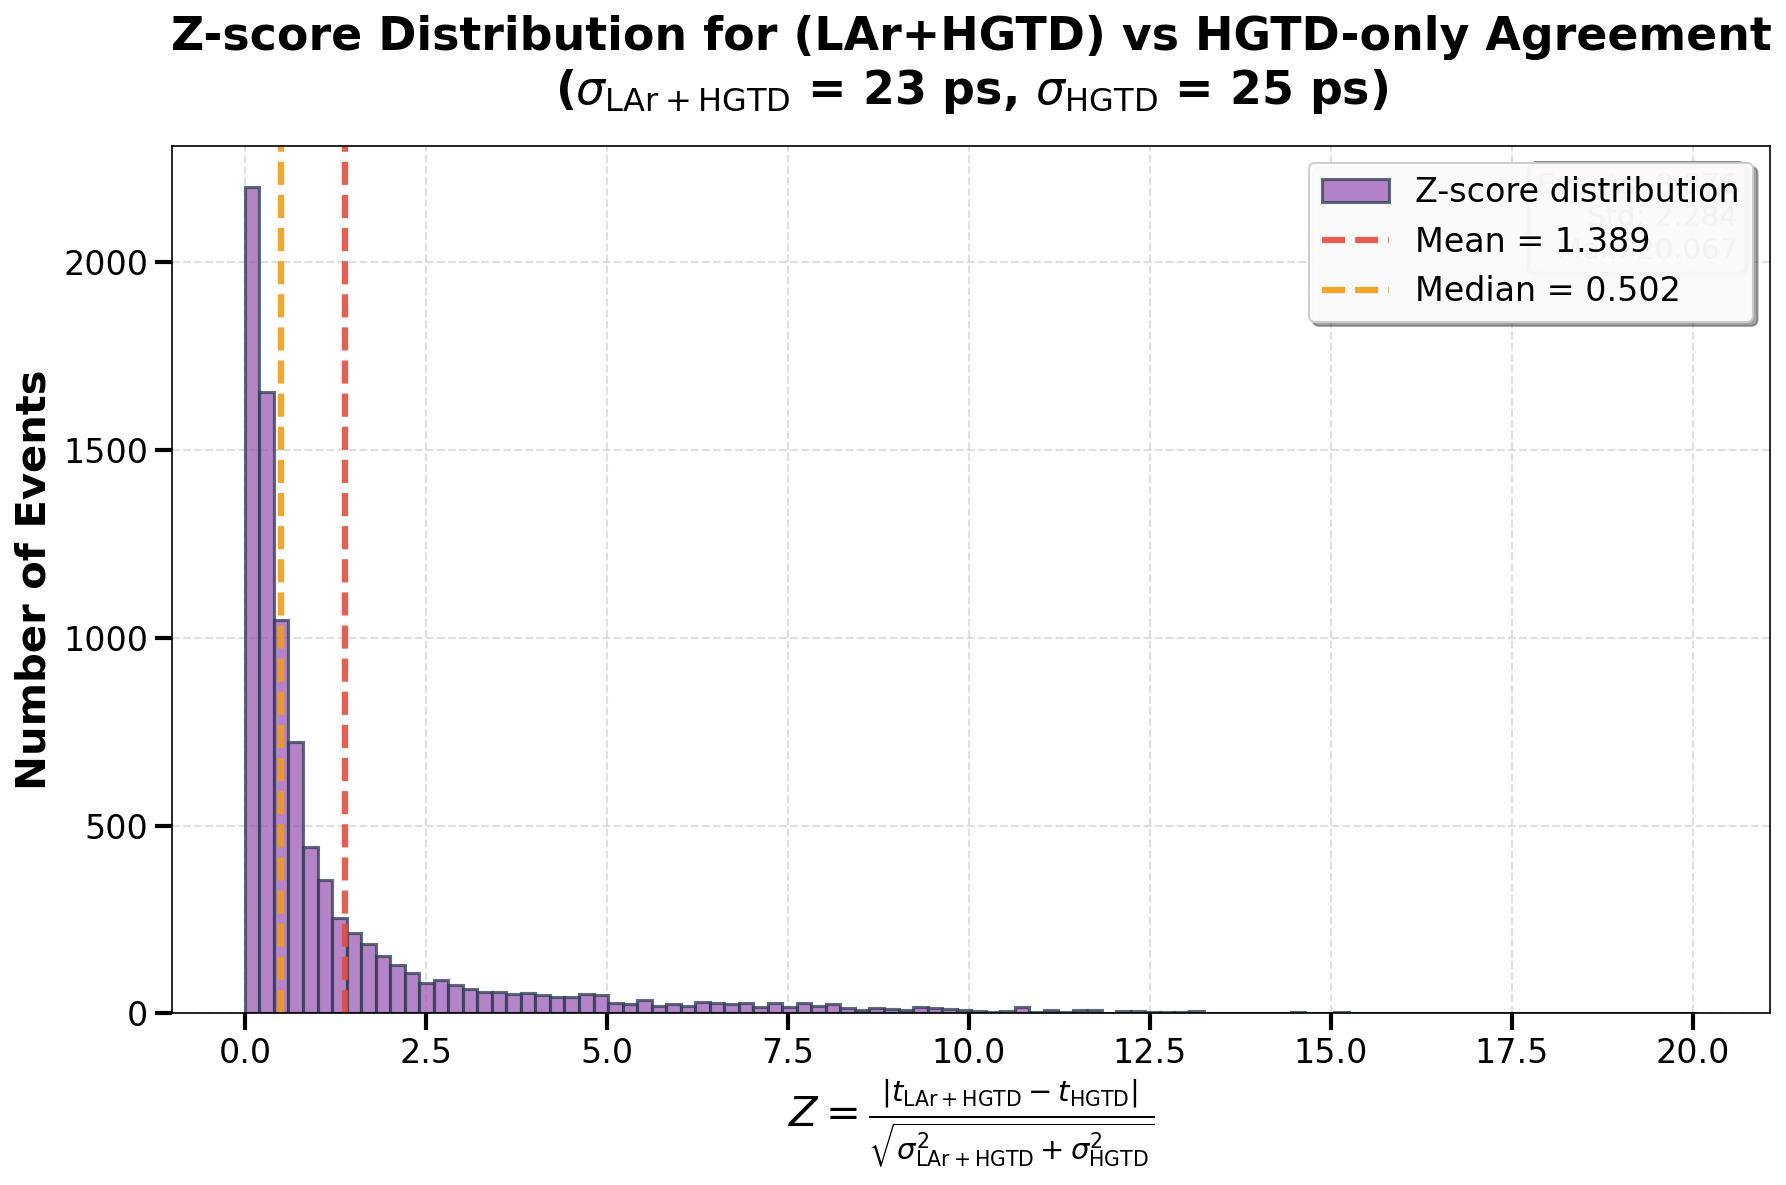

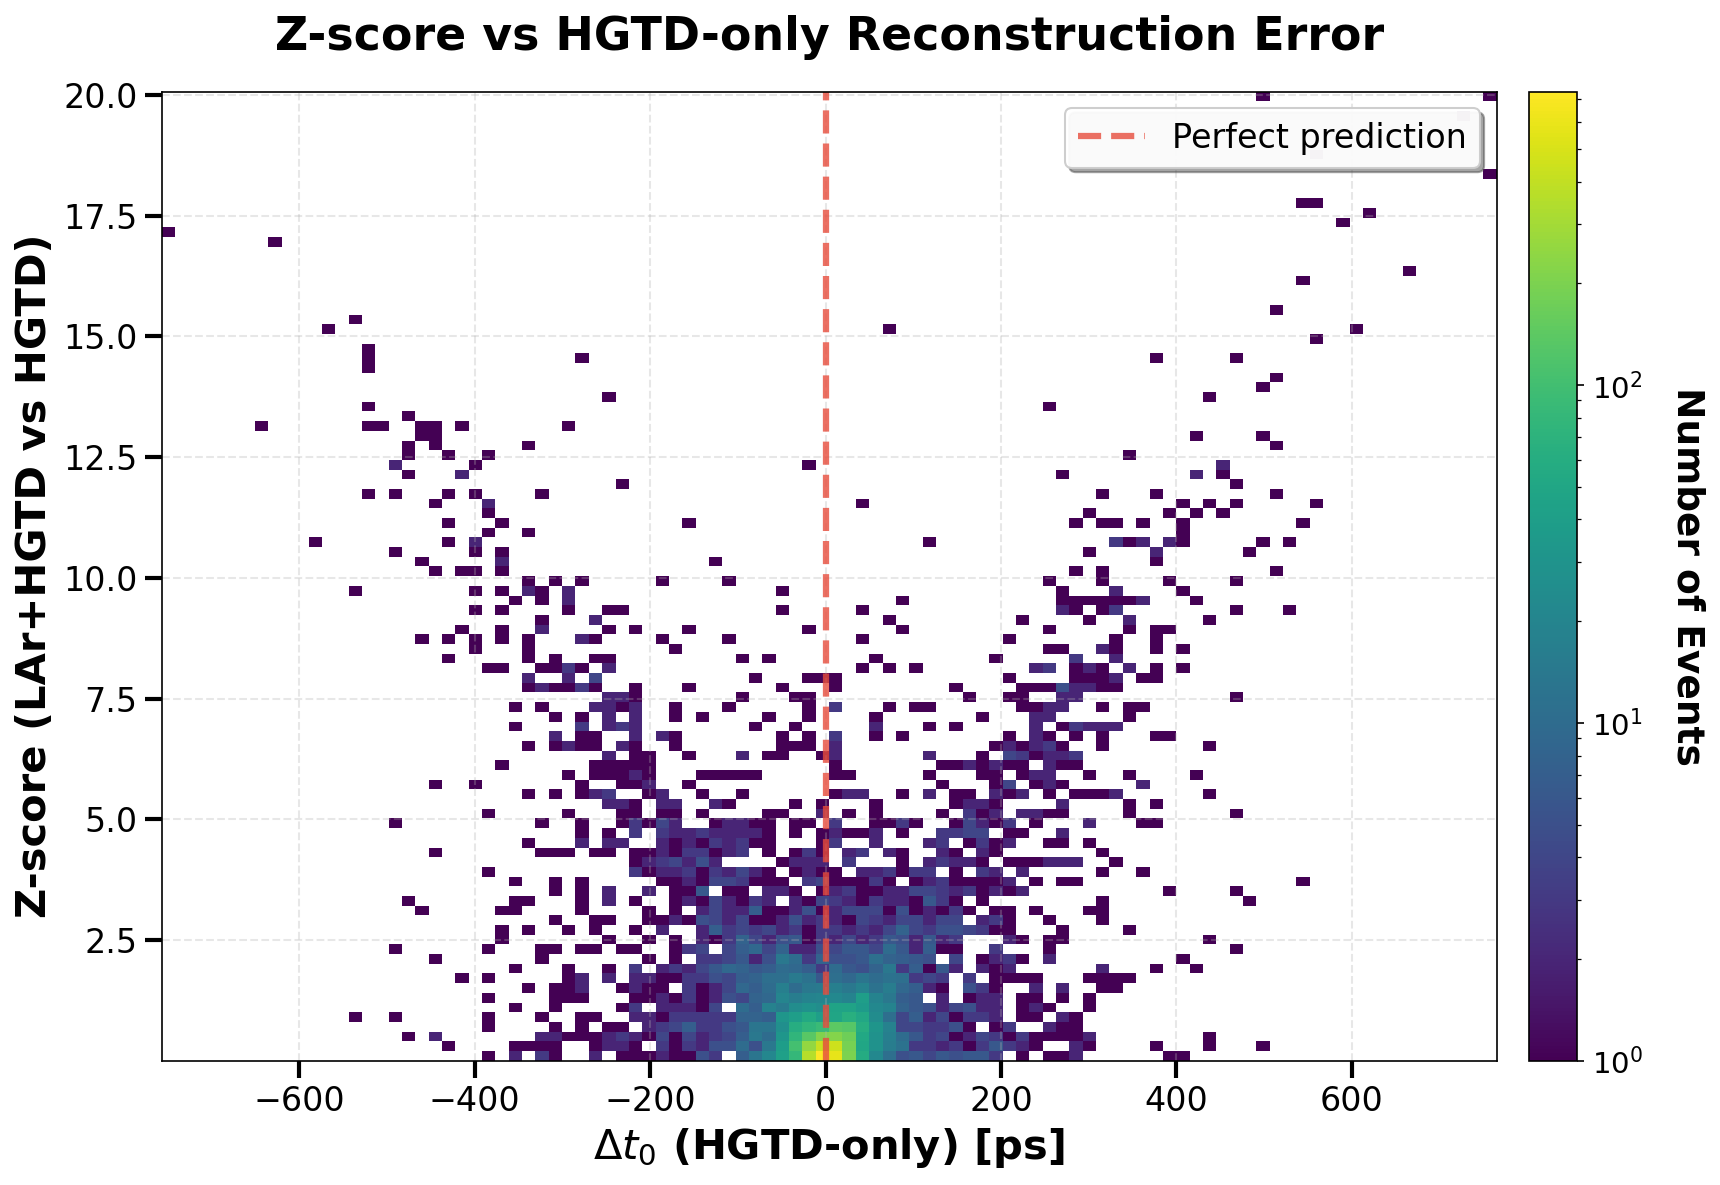

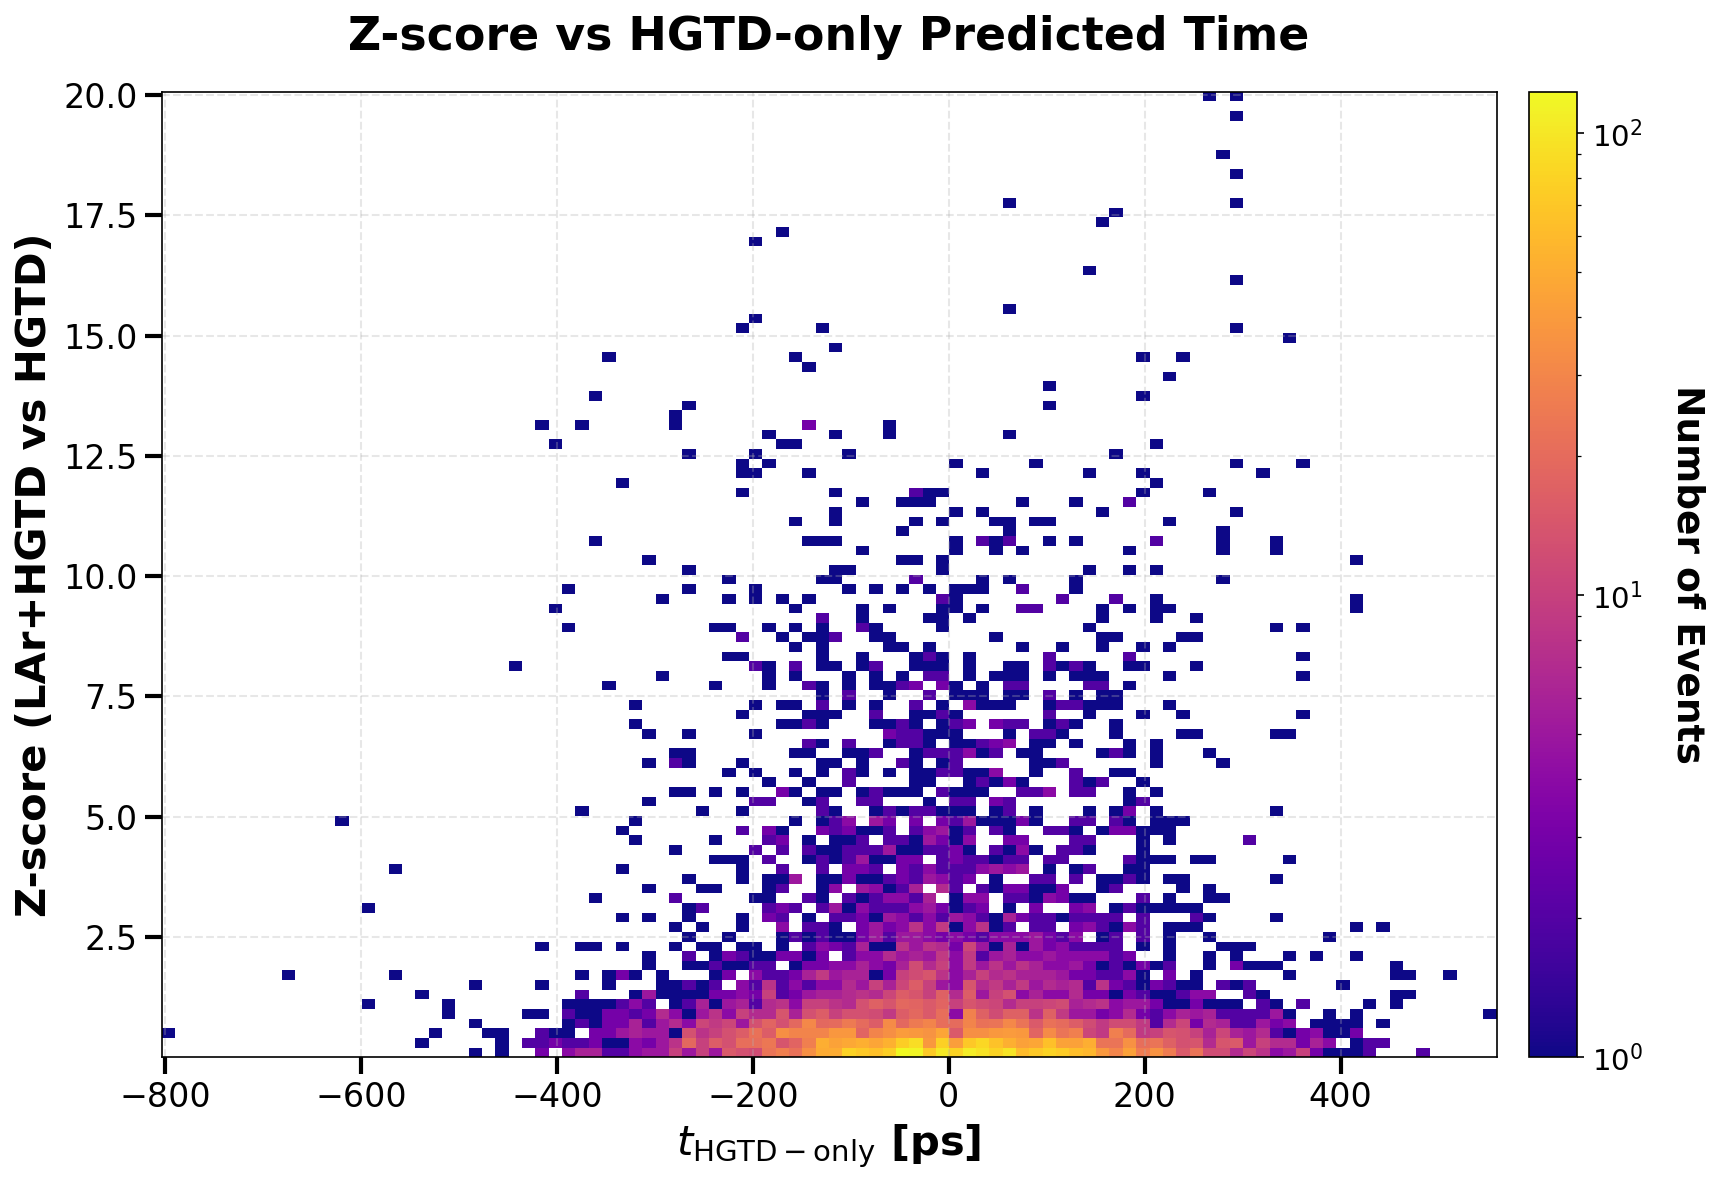

📊 Z-score Statistics (LAr+HGTD vs HGTD-only)
Mean Z-score:        1.3890
Median Z-score:      0.5017
Std Z-score:         2.2839
Max Z-score:         20.0666
Min Z-score:         0.0000

Events with Z > 1:   2810 (31.66%)
Events with Z > 2:   1653 (18.62%)
Events with Z > 3:   1168 (13.16%)

🔝 Top 10 Events with HIGHEST Z-score (LAr+HGTD vs HGTD-only)


,Index,Event_Num,File_Num,True t₀ [ps],LAr+HGTD [ps],HGTD-only [ps],Error (LAr+HGTD),Error (HGTD-only),Z_score_combined
6121,6121,145440,39,-504.972015,-421.909363,259.765015,83.062653,764.737061,20.066612
4516,4516,182969,31,-217.889175,-391.903717,286.897156,-174.014542,504.786316,19.982025
4375,4375,151576,14,-432.532837,-368.444244,294.715363,64.088593,727.248169,19.521587
1994,1994,124797,36,-273.207275,-352.429199,283.918274,-79.221924,557.125549,18.732313
599,599,107046,44,-470.200897,-328.817780,294.765045,141.383118,764.965942,18.356556
23,23,126466,5,-483.953522,-539.296936,67.139542,-55.343414,551.093079,17.851814
5165,5165,57914,47,-269.941254,-308.462555,291.809662,-38.521301,561.750916,17.670357
3956,3956,122655,19,-451.687286,-430.301971,167.948395,21.385315,619.635681,17.610840
7402,7402,68077,17,-424.420685,-429.601837,160.728226,-5.181152,585.148926,17.377687
8309,8309,147756,6,582.451843,409.342346,-174.424255,-173.109497,-756.876099,17.184477



🔻 Top 10 Events with LOWEST Z-score (LAr+HGTD vs HGTD-only)


,Index,Event_Num,File_Num,True t₀ [ps],LAr+HGTD [ps],HGTD-only [ps],Error (LAr+HGTD),Error (HGTD-only),Z_score_combined
3838,3838,16635,30,130.982971,115.485756,115.486259,-15.497215,-15.496712,0.000015
4794,4794,154119,38,160.908447,146.398102,146.398804,-14.510345,-14.509644,0.000021
4747,4747,109728,17,120.795044,108.297462,108.294701,-12.497581,-12.500343,0.000081
3600,3600,116070,12,-248.063629,-55.996708,-56.000042,192.066925,192.063583,0.000098
3101,3101,19789,11,114.183327,95.177849,95.185158,-19.005478,-18.998169,0.000215
7130,7130,129354,18,-320.494873,-312.767914,-312.775665,7.726959,7.719208,0.000228
1843,1843,18043,27,218.712753,209.776596,209.760773,-8.936157,-8.951981,0.000466
8127,8127,7352,7,-91.064590,-80.908836,-80.925224,10.155754,10.139366,0.000482
6531,6531,124075,20,-31.198639,-13.746289,-13.725716,17.452351,17.472923,0.000606
4851,4851,55143,21,121.692711,125.538010,125.558632,3.845299,3.865921,0.000607



📊 Summary of Extreme Z-score Events (LAr+HGTD vs HGTD-only)
Category             Mean Z-score    Mean |Error(LAr+HGTD)|    Mean |Error(HGTD)|  
------------------------------------------------------------------------------------------
Top 10 Highest              18.4354                  83.5312            639.3368
Top 10 Lowest                0.0003                  30.1694             30.1718


In [13]:
# Calculate Z-score: |t_LAr+HGTD - t_HGTD| / sqrt(sigma_LAr+HGTD^2 + sigma_HGTD^2)
sigma_lar_hgtd = 23  # ps (LAr+HGTD combined model)
sigma_hgtd = 25  # ps

df['Z_score_combined'] = np.abs(y_pred_lar_hgtd - y_pred_hgtd) / np.sqrt(sigma_lar_hgtd**2 + sigma_hgtd**2)

# ====================================================================
# Figure 1: Z-score Combined Distribution (High Quality, Beautiful)
# ====================================================================
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

# Plot histogram with beautiful styling
n, bins, patches = ax.hist(df['Z_score_combined'], bins=100, alpha=0.75, 
                           color='#9b59b6', edgecolor='#2c3e50', linewidth=1.5,
                           label='Z-score distribution')

# Add mean and median lines
mean_z = df['Z_score_combined'].mean()
median_z = df['Z_score_combined'].median()

ax.axvline(x=mean_z, color='#e74c3c', linestyle='--', linewidth=3, 
           label=f'Mean = {mean_z:.3f}', alpha=0.9)
ax.axvline(x=median_z, color='#f39c12', linestyle='--', linewidth=3,
           label=f'Median = {median_z:.3f}', alpha=0.9)

# Labels and title with larger fonts
ax.set_xlabel('$Z = \\frac{|t_{\\mathrm{LAr+HGTD}} - t_{\\mathrm{HGTD}}|}{\\sqrt{\\sigma_{\\mathrm{LAr+HGTD}}^2 + \\sigma_{\\mathrm{HGTD}}^2}}$', 
              fontsize=20, fontweight='bold')
ax.set_ylabel('Number of Events', fontsize=20, fontweight='bold')
ax.set_title(f'Z-score Distribution for (LAr+HGTD) vs HGTD-only Agreement\n($\\sigma_{{\\mathrm{{LAr+HGTD}}}}$ = {sigma_lar_hgtd} ps, $\\sigma_{{\\mathrm{{HGTD}}}}$ = {sigma_hgtd} ps)', 
             fontsize=22, fontweight='bold', pad=20)

# Enhanced legend
ax.legend(fontsize=16, loc='upper right', frameon=True, shadow=True, 
          fancybox=True, framealpha=0.95)

# Grid styling
ax.grid(True, alpha=0.4, linestyle='--', linewidth=1)
ax.set_axisbelow(True)

# Tick parameters
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=8)
ax.tick_params(axis='both', which='minor', labelsize=14, width=1.5, length=5)

# Add statistics box
stats_text = f'Events: {len(df):,}\nStd: {df["Z_score_combined"].std():.3f}\nMax: {df["Z_score_combined"].max():.3f}'
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
        fontsize=14, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#34495e', linewidth=2))

plt.tight_layout()
plt.show()

# ====================================================================
# Figure 2: Z-score vs HGTD Error (2D Histogram)
# ====================================================================
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

h = ax.hist2d(df['HGTD_error'], df['Z_score_combined'], bins=100, 
              cmap='viridis', cmin=1, norm=plt.matplotlib.colors.LogNorm())

# Colorbar
cbar = plt.colorbar(h[3], ax=ax, pad=0.02)
cbar.set_label('Number of Events', fontsize=18, fontweight='bold', rotation=270, labelpad=30)
cbar.ax.tick_params(labelsize=14)

# Perfect prediction line
ax.axvline(x=0, color='#e74c3c', linestyle='--', linewidth=3, 
           alpha=0.8, label='Perfect prediction')

# Labels and title
ax.set_xlabel('$\\Delta t_0$ (HGTD-only) [ps]', fontsize=20, fontweight='bold')
ax.set_ylabel('Z-score (LAr+HGTD vs HGTD)', fontsize=20, fontweight='bold')
ax.set_title('Z-score vs HGTD-only Reconstruction Error', 
             fontsize=22, fontweight='bold', pad=20)

# Legend
ax.legend(fontsize=16, loc='upper right', frameon=True, shadow=True, 
          fancybox=True, framealpha=0.95)

# Grid and ticks
ax.grid(True, alpha=0.3, linestyle='--', linewidth=1)
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=8)

plt.tight_layout()
plt.show()

# ====================================================================
# Figure 3: Z-score vs HGTD Prediction Value
# ====================================================================
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

h = ax.hist2d(y_pred_hgtd, df['Z_score_combined'], bins=100, 
              cmap='plasma', cmin=1, norm=plt.matplotlib.colors.LogNorm())

# Colorbar
cbar = plt.colorbar(h[3], ax=ax, pad=0.02)
cbar.set_label('Number of Events', fontsize=18, fontweight='bold', rotation=270, labelpad=30)
cbar.ax.tick_params(labelsize=14)

# Labels and title
ax.set_xlabel('$t_{\\mathrm{HGTD-only}}$ [ps]', fontsize=20, fontweight='bold')
ax.set_ylabel('Z-score (LAr+HGTD vs HGTD)', fontsize=20, fontweight='bold')
ax.set_title('Z-score vs HGTD-only Predicted Time', 
             fontsize=22, fontweight='bold', pad=20)

# Grid and ticks
ax.grid(True, alpha=0.3, linestyle='--', linewidth=1)
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=8)

plt.tight_layout()
plt.show()

# ====================================================================
# Print Statistics
# ====================================================================
print("📊 Z-score Statistics (LAr+HGTD vs HGTD-only)")
print("="*60)
print(f"Mean Z-score:        {df['Z_score_combined'].mean():.4f}")
print(f"Median Z-score:      {df['Z_score_combined'].median():.4f}")
print(f"Std Z-score:         {df['Z_score_combined'].std():.4f}")
print(f"Max Z-score:         {df['Z_score_combined'].max():.4f}")
print(f"Min Z-score:         {df['Z_score_combined'].min():.4f}")
print(f"\nEvents with Z > 1:   {(df['Z_score_combined'] > 1).sum()} ({100*(df['Z_score_combined'] > 1).sum()/len(df):.2f}%)")
print(f"Events with Z > 2:   {(df['Z_score_combined'] > 2).sum()} ({100*(df['Z_score_combined'] > 2).sum()/len(df):.2f}%)")
print(f"Events with Z > 3:   {(df['Z_score_combined'] > 3).sum()} ({100*(df['Z_score_combined'] > 3).sum()/len(df):.2f}%)")

# Top 10 highest Z-score_combined events
print("\n" + "="*120)
print("🔝 Top 10 Events with HIGHEST Z-score (LAr+HGTD vs HGTD-only)")
print("="*120)
top_10_high = df.nlargest(10, 'Z_score_combined')
display_cols = ['Index']
if has_metadata:
    display_cols.extend(['Event_Num', 'File_Num'])
display_cols.extend(['True t₀ [ps]', 'LAr+HGTD [ps]', 'HGTD-only [ps]', 
                    'Error (LAr+HGTD)', 'Error (HGTD-only)', 'Z_score_combined'])
display(top_10_high[display_cols])

# Top 10 lowest Z-score_combined events
print("\n" + "="*120)
print("🔻 Top 10 Events with LOWEST Z-score (LAr+HGTD vs HGTD-only)")
print("="*120)
top_10_low = df.nsmallest(10, 'Z_score_combined')
display(top_10_low[display_cols])

# Summary statistics for these events
print("\n📊 Summary of Extreme Z-score Events (LAr+HGTD vs HGTD-only)")
print("="*90)
print(f"{'Category':<20} {'Mean Z-score':<15} {'Mean |Error(LAr+HGTD)|':<25} {'Mean |Error(HGTD)|':<20}")
print("-"*90)
print(f"{'Top 10 Highest':<20} {top_10_high['Z_score_combined'].mean():>14.4f} "
      f"{top_10_high['Error (LAr+HGTD)'].abs().mean():>24.4f} "
      f"{top_10_high['Error (HGTD-only)'].abs().mean():>19.4f}")
print(f"{'Top 10 Lowest':<20} {top_10_low['Z_score_combined'].mean():>14.4f} "
      f"{top_10_low['Error (LAr+HGTD)'].abs().mean():>24.4f} "
      f"{top_10_low['Error (HGTD-only)'].abs().mean():>19.4f}")

📊 Applying Z-score cut: Z_combined ≤ 1.0
Events before cut: 8876 (100.00%)
Events after cut:  6066 (68.34%)
Events removed:    2810 (31.66%)


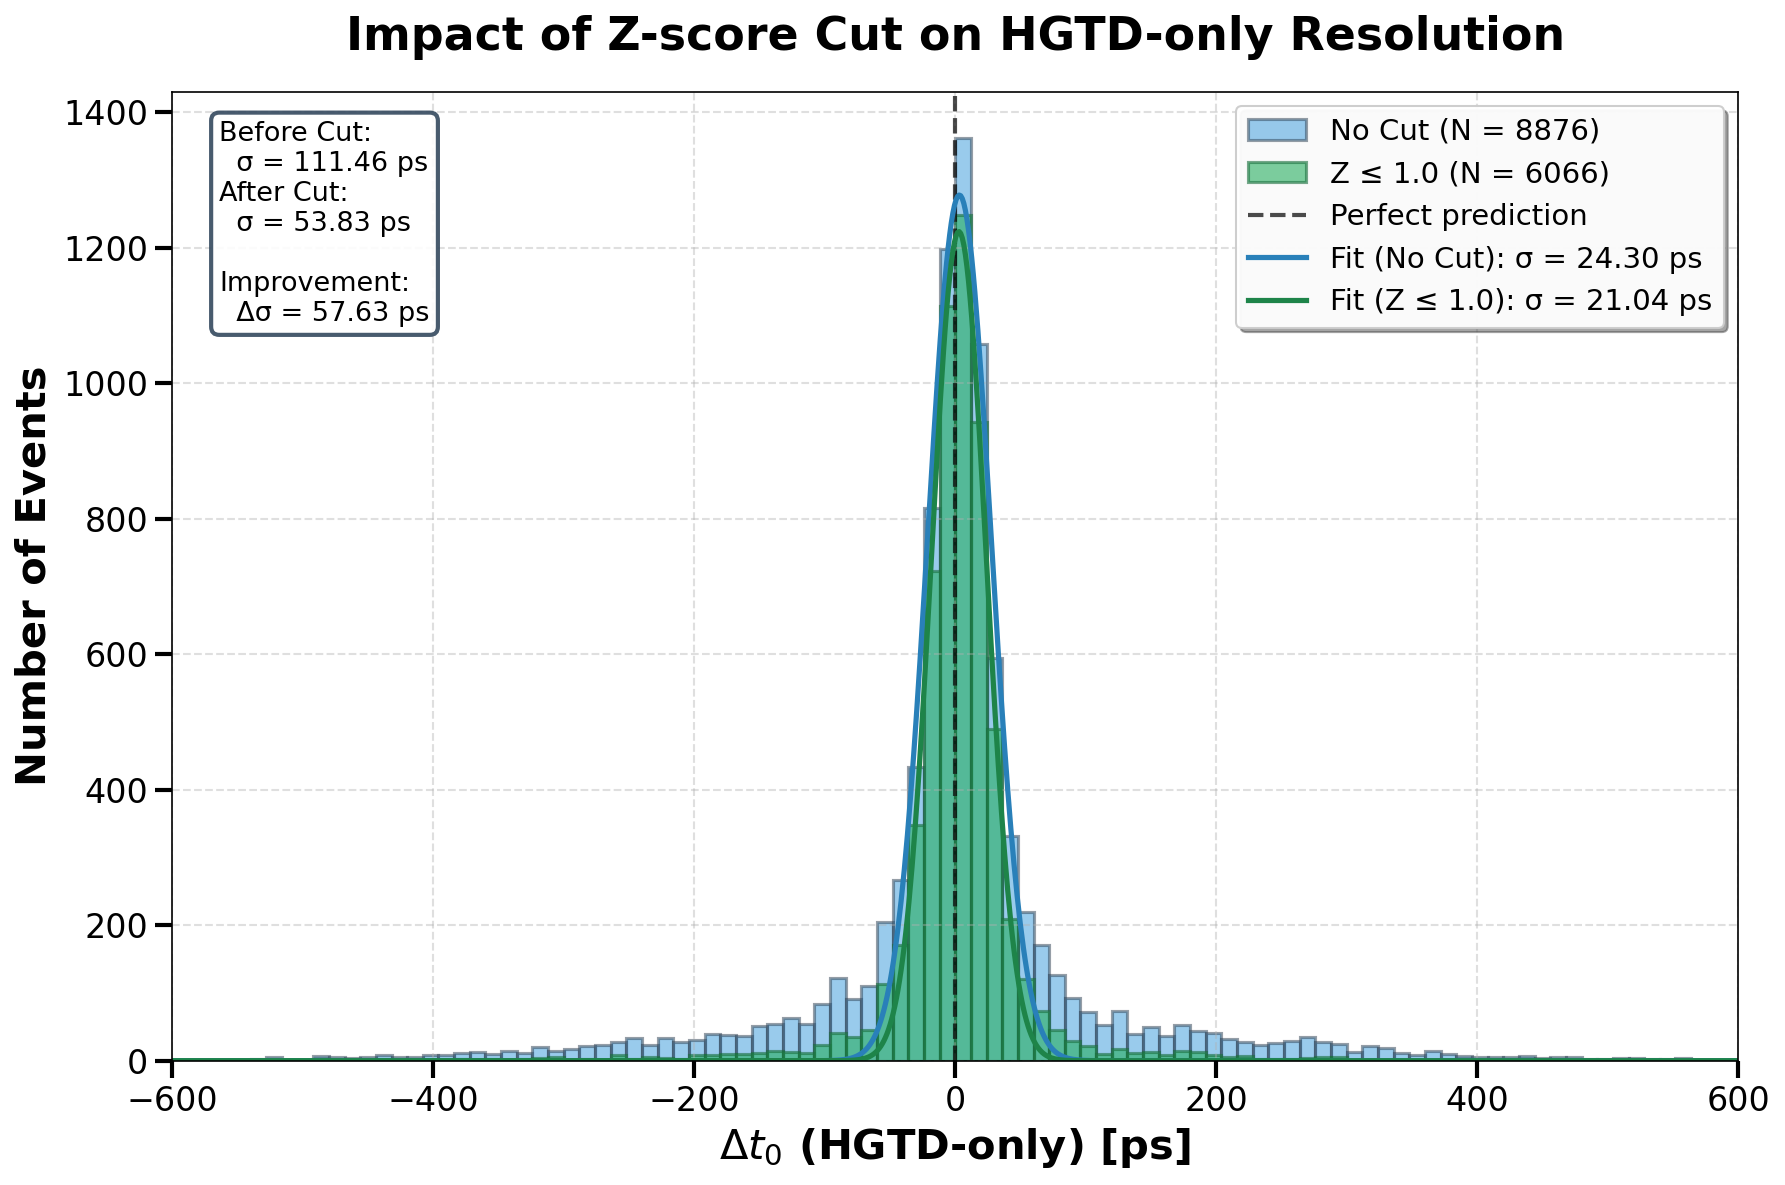


📊 HGTD-only Performance Comparison
Metric               No Cut               Z ≤ 1.0              Improvement         
--------------------------------------------------------------------------------
Mean [ps]                         3.3631              1.5612              1.8020
Std [ps]                        111.4573             53.8254             57.6318
RMSE [ps]                       111.5080             53.8481             57.6599


In [18]:
from scipy.optimize import curve_fit

# Gaussian function
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean)**2) / (2 * sigma**2))

# Specify Z-score cut threshold
z_cut = 1.0  # Cut for Z_score_combined (LAr+HGTD vs HGTD)

# Apply Z-score cut
df_filtered = df[df['Z_score_combined'] <= z_cut].copy()

print(f"📊 Applying Z-score cut: Z_combined ≤ {z_cut}")
print("="*80)
print(f"Events before cut: {len(df)} (100.00%)")
print(f"Events after cut:  {len(df_filtered)} ({100*len(df_filtered)/len(df):.2f}%)")
print(f"Events removed:    {len(df) - len(df_filtered)} ({100*(len(df) - len(df_filtered))/len(df):.2f}%)")
print("="*80)

# Plot comparison on single figure
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

# Before cut (blue)
data_before = df['Error (HGTD-only)']
n1, bins1, _ = ax.hist(data_before, bins=100, alpha=0.5, color='#3498db', 
                       edgecolor='#2c3e50', linewidth=1.5, label=f'No Cut (N = {len(df)})', 
                       range=(-600, 600))

# After cut (green)
data_after = df_filtered['Error (HGTD-only)']
n2, bins2, _ = ax.hist(data_after, bins=100, alpha=0.6, color='#27ae60', 
                       edgecolor='#196f3d', linewidth=1.5, 
                       label=f'Z ≤ {z_cut} (N = {len(df_filtered)})', range=(-600, 600))

# Zero line
ax.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.7, label='Perfect prediction')

# Gaussian fits
bin_centers1 = (bins1[:-1] + bins1[1:]) / 2
popt1, _ = curve_fit(gaussian, bin_centers1, n1, p0=[n1.max(), data_before.mean(), data_before.std()])
x_fit = np.linspace(-600, 600, 1000)
ax.plot(x_fit, gaussian(x_fit, *popt1), color='#2980b9', linestyle='-', linewidth=2.5, 
        label=f'Fit (No Cut): σ = {abs(popt1[2]):.2f} ps')

bin_centers2 = (bins2[:-1] + bins2[1:]) / 2
popt2, _ = curve_fit(gaussian, bin_centers2, n2, p0=[n2.max(), data_after.mean(), data_after.std()])
ax.plot(x_fit, gaussian(x_fit, *popt2), color='#1e8449', linestyle='-', linewidth=2.5, 
        label=f'Fit (Z ≤ {z_cut}): σ = {abs(popt2[2]):.2f} ps')

# Labels and styling
ax.set_xlabel('$\\Delta t_0$ (HGTD-only) [ps]', fontsize=20, fontweight='bold')
ax.set_ylabel('Number of Events', fontsize=20, fontweight='bold')
ax.set_title(f'Impact of Z-score Cut on HGTD-only Resolution', fontsize=22, fontweight='bold', pad=20)
ax.set_xlim(-600, 600)
ax.legend(fontsize=14, loc='upper right', frameon=True, shadow=True, fancybox=True, framealpha=0.95)
ax.grid(True, alpha=0.4, linestyle='--', linewidth=1)
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=8)

# Statistics box
stats_text = f'Before Cut:\n  σ = {data_before.std():.2f} ps\n'
stats_text += f'After Cut:\n  σ = {data_after.std():.2f} ps\n\n'
stats_text += f'Improvement:\n  Δσ = {data_before.std() - data_after.std():.2f} ps'
ax.text(0.03, 0.97, stats_text, transform=ax.transAxes, fontsize=13,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', 
        alpha=0.9, edgecolor='#34495e', linewidth=2))

plt.tight_layout()
plt.show()

# Print detailed statistics
print(f"\n📊 HGTD-only Performance Comparison")
print("="*80)
print(f"{'Metric':<20} {'No Cut':<20} {'Z ≤ ' + str(z_cut):<20} {'Improvement':<20}")
print("-"*80)
for metric, func in [('Mean [ps]', np.mean), ('Std [ps]', np.std), 
                     ('RMSE [ps]', lambda x: np.sqrt((x**2).mean()))]:
    before = func(data_before)
    after = func(data_after)
    print(f"{metric:<20} {before:>19.4f} {after:>19.4f} {before - after:>19.4f}")

📊 Applying Z-score cuts: Z₁ ≤ 1.0 AND Z₂ ≤ 1.0
Events before cut: 8876
Events after cut:  4072 (45.88%)
Events removed:    4804 (54.12%)


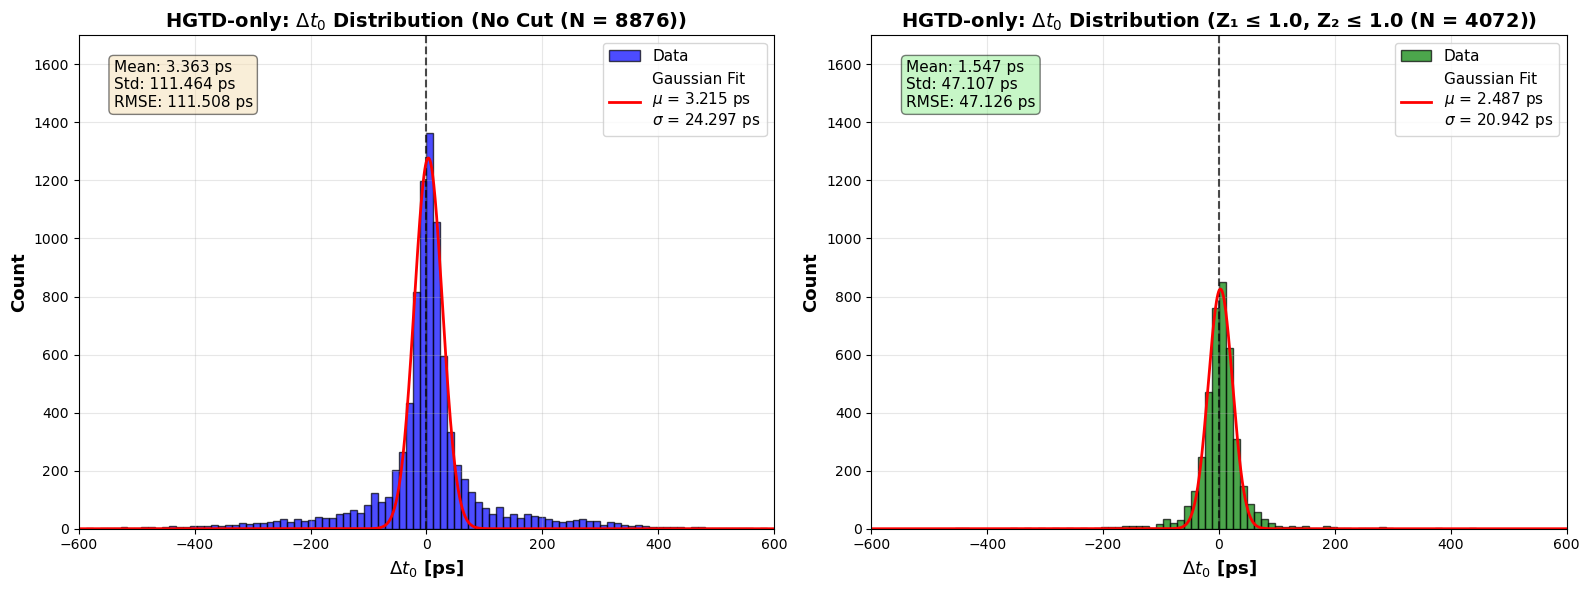


📊 HGTD-only Performance Comparison
Metric               No Cut               With Cuts            Improvement         
--------------------------------------------------------------------------------
Mean [ps]                         3.3631              1.5467              1.8165
Std [ps]                        111.4573             47.1011             64.3562
RMSE [ps]                       111.5080             47.1265             64.3815

📊 Cut Breakdown
Events passing Z₁ ≤ 1.0:           4984 (56.15%)
Events passing Z₂ ≤ 1.0:           6066 (68.34%)
Events passing both cuts:      4072 (45.88%)


In [14]:
from scipy.optimize import curve_fit

# Gaussian function
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-((x - mean)**2) / (2 * sigma**2))

# Specify Z-score cut thresholds
z_cut_1 = 1.0  # Cut for Z_score (LAr vs HGTD)
z_cut_2 = 1.0  # Cut for Z_score_combined (LAr+HGTD vs HGTD)

# Apply both Z-score cuts
df_filtered = df[(df['Z_score'] <= z_cut_1) & (df['Z_score_combined'] <= z_cut_2)].copy()

print(f"📊 Applying Z-score cuts: Z₁ ≤ {z_cut_1} AND Z₂ ≤ {z_cut_2}")
print("="*80)
print(f"Events before cut: {len(df)}")
print(f"Events after cut:  {len(df_filtered)} ({100*len(df_filtered)/len(df):.2f}%)")
print(f"Events removed:    {len(df) - len(df_filtered)} ({100*(len(df) - len(df_filtered))/len(df):.2f}%)")
print("="*80)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (data, title, color) in enumerate([
    (df['Error (HGTD-only)'], f'No Cut (N = {len(df)})', 'blue'),
    (df_filtered['Error (HGTD-only)'], f'Z₁ ≤ {z_cut_1}, Z₂ ≤ {z_cut_2} (N = {len(df_filtered)})', 'green')
]):
    # Histogram
    n, bins, _ = axes[idx].hist(data, bins=100, alpha=0.7, color=color, edgecolor='black', label='Data', range=(-600, 600))
    axes[idx].axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Gaussian fit
    bin_centers = (bins[:-1] + bins[1:]) / 2
    popt, _ = curve_fit(gaussian, bin_centers, n, p0=[n.max(), data.mean(), data.std()])
    x_fit = np.linspace(bins[0], bins[-1], 1000)
    axes[idx].plot(x_fit, gaussian(x_fit, *popt), 'r-', linewidth=2, 
                   label=f'Gaussian Fit\n$\\mu$ = {popt[1]:.3f} ps\n$\\sigma$ = {abs(popt[2]):.3f} ps')
    
    # Labels and text
    axes[idx].set_xlabel('$\\Delta t_0$ [ps]', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Count', fontsize=13, fontweight='bold')
    axes[idx].set_title(f'HGTD-only: $\\Delta t_0$ Distribution ({title})', fontsize=14, fontweight='bold')
    axes[idx].set_xlim(-600, 600)
    axes[idx].set_ylim(0, 1700)
    axes[idx].legend(fontsize=11, loc='upper right')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].text(0.05, 0.95, f'Mean: {data.mean():.3f} ps\nStd: {data.std():.3f} ps\nRMSE: {np.sqrt((data**2).mean()):.3f} ps',
                   transform=axes[idx].transAxes, fontsize=11, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat' if idx==0 else 'lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()

# Print statistics
print(f"\n📊 HGTD-only Performance Comparison")
print("="*80)
print(f"{'Metric':<20} {'No Cut':<20} {'With Cuts':<20} {'Improvement':<20}")
print("-"*80)
for metric, func in [('Mean [ps]', np.mean), ('Std [ps]', np.std), ('RMSE [ps]', lambda x: np.sqrt((x**2).mean()))]:
    before, after = func(df['Error (HGTD-only)']), func(df_filtered['Error (HGTD-only)'])
    print(f"{metric:<20} {before:>19.4f} {after:>19.4f} {before - after:>19.4f}")

# Print cut breakdown
print(f"\n📊 Cut Breakdown")
print("="*80)
print(f"Events passing Z₁ ≤ {z_cut_1}:           {(df['Z_score'] <= z_cut_1).sum()} ({100*(df['Z_score'] <= z_cut_1).sum()/len(df):.2f}%)")
print(f"Events passing Z₂ ≤ {z_cut_2}:           {(df['Z_score_combined'] <= z_cut_2).sum()} ({100*(df['Z_score_combined'] <= z_cut_2).sum()/len(df):.2f}%)")
print(f"Events passing both cuts:      {len(df_filtered)} ({100*len(df_filtered)/len(df):.2f}%)")

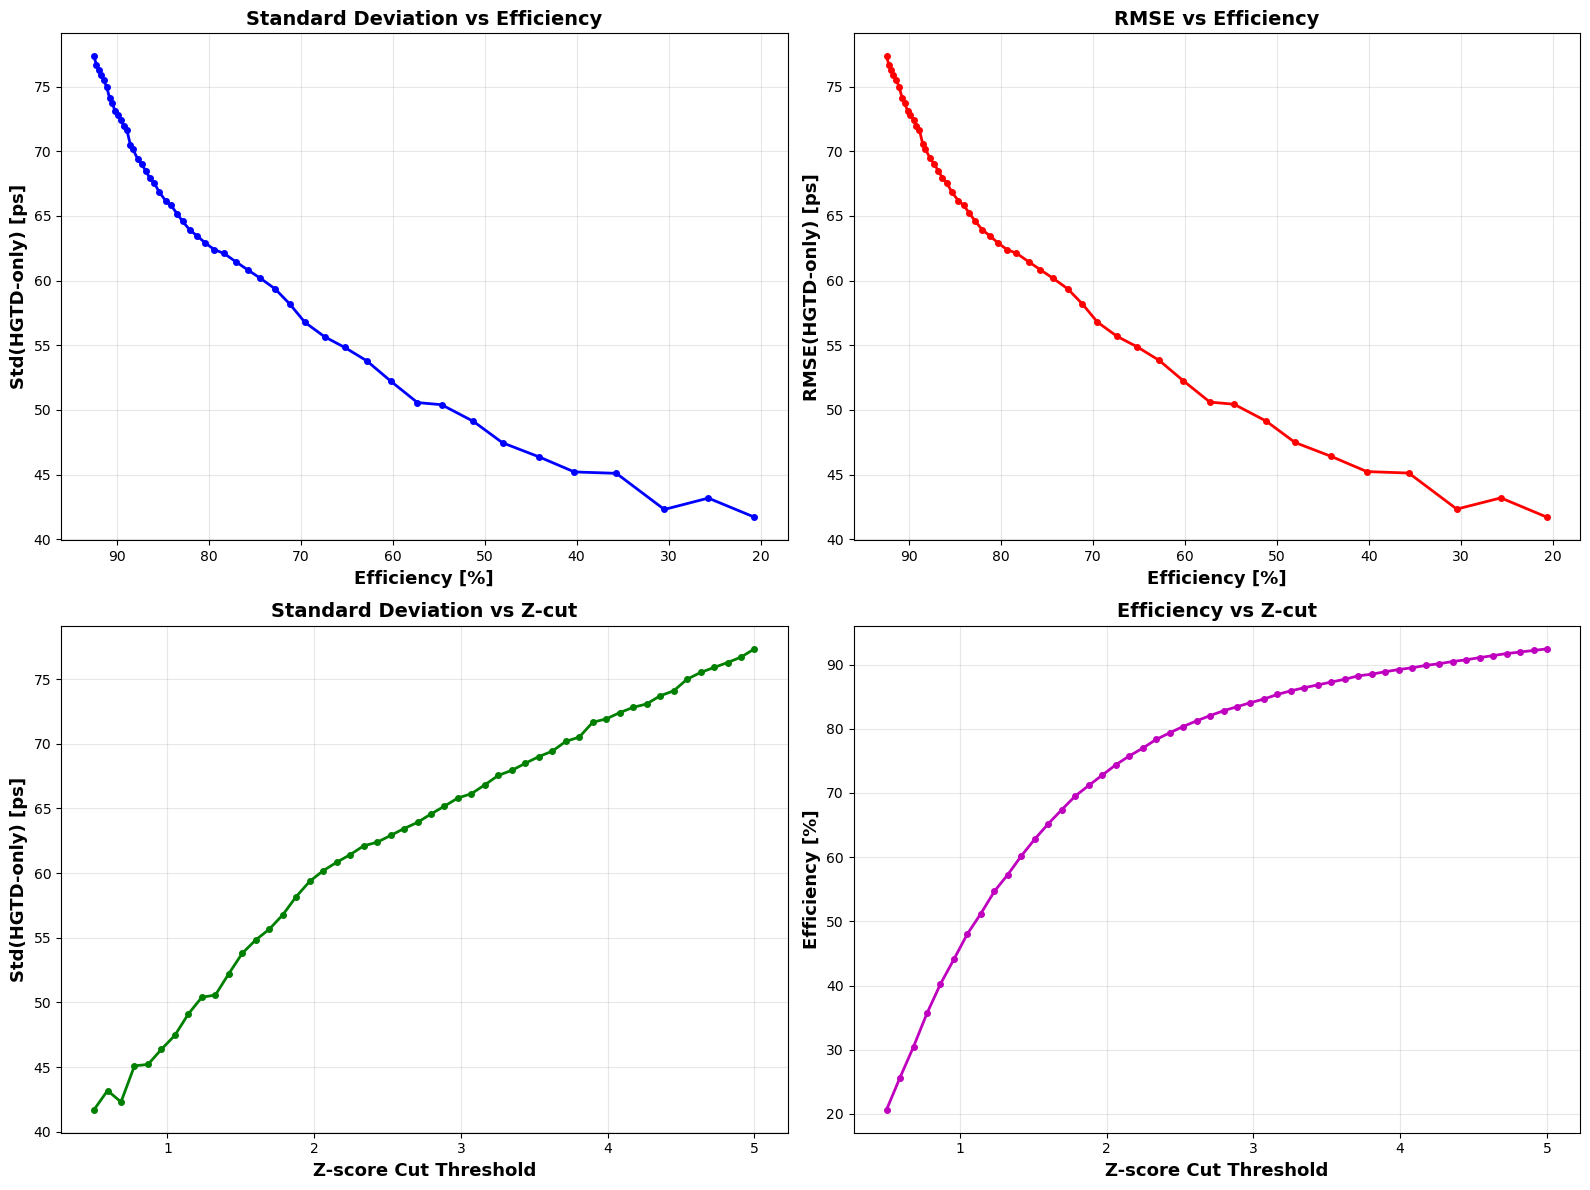


📊 Scan Results Summary
Z-cut      Efficiency [%]  Std [ps]        RMSE [ps]      
--------------------------------------------------------------------------------
0.50       20.66           41.710          41.699         
1.60       65.21           54.838          54.877         
2.80       82.81           64.573          64.592         
3.90       88.89           71.666          71.685         
5.00       92.45           77.340          77.346         


In [15]:
# Scan over different Z-score cut values
z_scan_values = np.linspace(0.5, 5.0, 50)  # Scan from 0.5 to 5.0

efficiencies = []
std_values = []
mean_values = []
rmse_values = []

for z_threshold in z_scan_values:
    # Apply symmetric cuts on both Z-scores
    df_scan = df[(df['Z_score'] <= z_threshold) & (df['Z_score_combined'] <= z_threshold)]
    
    # Calculate efficiency
    efficiency = len(df_scan) / len(df) * 100
    efficiencies.append(efficiency)
    
    # Calculate performance metrics
    if len(df_scan) > 0:
        std_values.append(df_scan['Error (HGTD-only)'].std())
        mean_values.append(df_scan['Error (HGTD-only)'].mean())
        rmse_values.append(np.sqrt((df_scan['Error (HGTD-only)']**2).mean()))
    else:
        std_values.append(np.nan)
        mean_values.append(np.nan)
        rmse_values.append(np.nan)

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Std vs Efficiency
axes[0, 0].plot(efficiencies, std_values, 'b-', linewidth=2, marker='o', markersize=4)
axes[0, 0].set_xlabel('Efficiency [%]', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Std(HGTD-only) [ps]', fontsize=13, fontweight='bold')
axes[0, 0].set_title('Standard Deviation vs Efficiency', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].invert_xaxis()  # Higher efficiency on the right

# Plot 2: RMSE vs Efficiency
axes[0, 1].plot(efficiencies, rmse_values, 'r-', linewidth=2, marker='o', markersize=4)
axes[0, 1].set_xlabel('Efficiency [%]', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('RMSE(HGTD-only) [ps]', fontsize=13, fontweight='bold')
axes[0, 1].set_title('RMSE vs Efficiency', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].invert_xaxis()

# Plot 3: Std vs Z-cut threshold
axes[1, 0].plot(z_scan_values, std_values, 'g-', linewidth=2, marker='o', markersize=4)
axes[1, 0].set_xlabel('Z-score Cut Threshold', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Std(HGTD-only) [ps]', fontsize=13, fontweight='bold')
axes[1, 0].set_title('Standard Deviation vs Z-cut', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Efficiency vs Z-cut threshold
axes[1, 1].plot(z_scan_values, efficiencies, 'm-', linewidth=2, marker='o', markersize=4)
axes[1, 1].set_xlabel('Z-score Cut Threshold', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Efficiency [%]', fontsize=13, fontweight='bold')
axes[1, 1].set_title('Efficiency vs Z-cut', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print some key points
print("\n📊 Scan Results Summary")
print("="*80)
print(f"{'Z-cut':<10} {'Efficiency [%]':<15} {'Std [ps]':<15} {'RMSE [ps]':<15}")
print("-"*80)
for i in [0, len(z_scan_values)//4, len(z_scan_values)//2, 3*len(z_scan_values)//4, -1]:
    print(f"{z_scan_values[i]:<10.2f} {efficiencies[i]:<15.2f} {std_values[i]:<15.3f} {rmse_values[i]:<15.3f}")

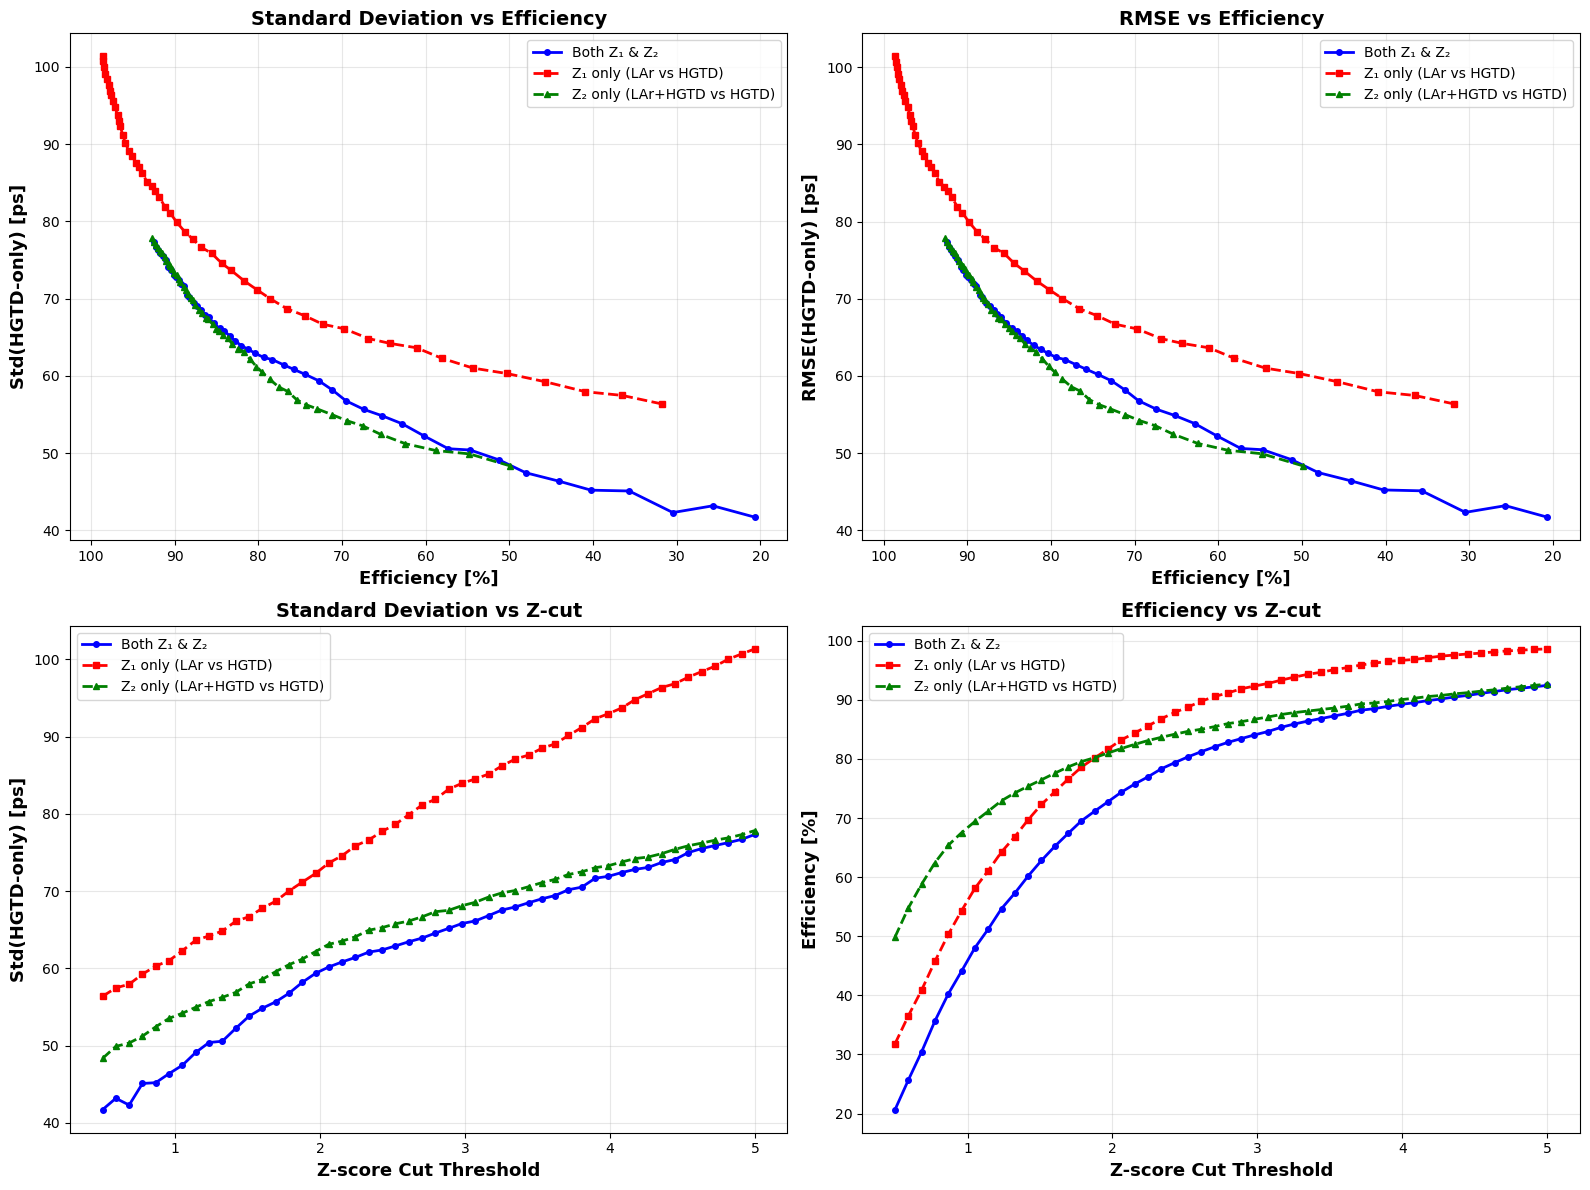


📊 Scan Results Comparison
Z-cut    Strategy             Efficiency [%]  Std [ps]        RMSE [ps]      
----------------------------------------------------------------------------------------------------
0.50     Both Z₁ & Z₂         20.66           41.710          41.699         
         Z₁ only              31.82           56.378          56.369         
         Z₂ only              49.88           48.338          48.346         
----------------------------------------------------------------------------------------------------
1.60     Both Z₁ & Z₂         65.21           54.838          54.877         
         Z₁ only              74.44           67.777          67.784         
         Z₂ only              77.59           58.577          58.611         
----------------------------------------------------------------------------------------------------
2.80     Both Z₁ & Z₂         82.81           64.573          64.592         
         Z₁ only              91.17           

In [16]:
# Scan over different Z-score cut values
z_scan_values = np.linspace(0.5, 5.0, 50)  # Scan from 0.5 to 5.0

# Storage for both Z-scores combined
efficiencies_both = []
std_values_both = []
mean_values_both = []
rmse_values_both = []

# Storage for Z_score only (LAr vs HGTD)
efficiencies_z1 = []
std_values_z1 = []
mean_values_z1 = []
rmse_values_z1 = []

# Storage for Z_score_combined only (LAr+HGTD vs HGTD)
efficiencies_z2 = []
std_values_z2 = []
mean_values_z2 = []
rmse_values_z2 = []

for z_threshold in z_scan_values:
    # Apply cuts with both Z-scores
    df_both = df[(df['Z_score'] <= z_threshold) & (df['Z_score_combined'] <= z_threshold)]
    efficiencies_both.append(len(df_both) / len(df) * 100)
    std_values_both.append(df_both['Error (HGTD-only)'].std() if len(df_both) > 0 else np.nan)
    mean_values_both.append(df_both['Error (HGTD-only)'].mean() if len(df_both) > 0 else np.nan)
    rmse_values_both.append(np.sqrt((df_both['Error (HGTD-only)']**2).mean()) if len(df_both) > 0 else np.nan)
    
    # Apply cut with Z_score only
    df_z1 = df[df['Z_score'] <= z_threshold]
    efficiencies_z1.append(len(df_z1) / len(df) * 100)
    std_values_z1.append(df_z1['Error (HGTD-only)'].std() if len(df_z1) > 0 else np.nan)
    mean_values_z1.append(df_z1['Error (HGTD-only)'].mean() if len(df_z1) > 0 else np.nan)
    rmse_values_z1.append(np.sqrt((df_z1['Error (HGTD-only)']**2).mean()) if len(df_z1) > 0 else np.nan)
    
    # Apply cut with Z_score_combined only
    df_z2 = df[df['Z_score_combined'] <= z_threshold]
    efficiencies_z2.append(len(df_z2) / len(df) * 100)
    std_values_z2.append(df_z2['Error (HGTD-only)'].std() if len(df_z2) > 0 else np.nan)
    mean_values_z2.append(df_z2['Error (HGTD-only)'].mean() if len(df_z2) > 0 else np.nan)
    rmse_values_z2.append(np.sqrt((df_z2['Error (HGTD-only)']**2).mean()) if len(df_z2) > 0 else np.nan)

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Std vs Efficiency
axes[0, 0].plot(efficiencies_both, std_values_both, 'b-', linewidth=2, marker='o', markersize=4, label='Both Z₁ & Z₂')
axes[0, 0].plot(efficiencies_z1, std_values_z1, 'r--', linewidth=2, marker='s', markersize=4, label='Z₁ only (LAr vs HGTD)')
axes[0, 0].plot(efficiencies_z2, std_values_z2, 'g--', linewidth=2, marker='^', markersize=4, label='Z₂ only (LAr+HGTD vs HGTD)')
axes[0, 0].set_xlabel('Efficiency [%]', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Std(HGTD-only) [ps]', fontsize=13, fontweight='bold')
axes[0, 0].set_title('Standard Deviation vs Efficiency', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].invert_xaxis()

# Plot 2: RMSE vs Efficiency
axes[0, 1].plot(efficiencies_both, rmse_values_both, 'b-', linewidth=2, marker='o', markersize=4, label='Both Z₁ & Z₂')
axes[0, 1].plot(efficiencies_z1, rmse_values_z1, 'r--', linewidth=2, marker='s', markersize=4, label='Z₁ only (LAr vs HGTD)')
axes[0, 1].plot(efficiencies_z2, rmse_values_z2, 'g--', linewidth=2, marker='^', markersize=4, label='Z₂ only (LAr+HGTD vs HGTD)')
axes[0, 1].set_xlabel('Efficiency [%]', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('RMSE(HGTD-only) [ps]', fontsize=13, fontweight='bold')
axes[0, 1].set_title('RMSE vs Efficiency', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].invert_xaxis()

# Plot 3: Std vs Z-cut threshold
axes[1, 0].plot(z_scan_values, std_values_both, 'b-', linewidth=2, marker='o', markersize=4, label='Both Z₁ & Z₂')
axes[1, 0].plot(z_scan_values, std_values_z1, 'r--', linewidth=2, marker='s', markersize=4, label='Z₁ only (LAr vs HGTD)')
axes[1, 0].plot(z_scan_values, std_values_z2, 'g--', linewidth=2, marker='^', markersize=4, label='Z₂ only (LAr+HGTD vs HGTD)')
axes[1, 0].set_xlabel('Z-score Cut Threshold', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Std(HGTD-only) [ps]', fontsize=13, fontweight='bold')
axes[1, 0].set_title('Standard Deviation vs Z-cut', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Efficiency vs Z-cut threshold
axes[1, 1].plot(z_scan_values, efficiencies_both, 'b-', linewidth=2, marker='o', markersize=4, label='Both Z₁ & Z₂')
axes[1, 1].plot(z_scan_values, efficiencies_z1, 'r--', linewidth=2, marker='s', markersize=4, label='Z₁ only (LAr vs HGTD)')
axes[1, 1].plot(z_scan_values, efficiencies_z2, 'g--', linewidth=2, marker='^', markersize=4, label='Z₂ only (LAr+HGTD vs HGTD)')
axes[1, 1].set_xlabel('Z-score Cut Threshold', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Efficiency [%]', fontsize=13, fontweight='bold')
axes[1, 1].set_title('Efficiency vs Z-cut', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison at key points
print("\n📊 Scan Results Comparison")
print("="*100)
print(f"{'Z-cut':<8} {'Strategy':<20} {'Efficiency [%]':<15} {'Std [ps]':<15} {'RMSE [ps]':<15}")
print("-"*100)
for i in [0, len(z_scan_values)//4, len(z_scan_values)//2, 3*len(z_scan_values)//4, -1]:
    print(f"{z_scan_values[i]:<8.2f} {'Both Z₁ & Z₂':<20} {efficiencies_both[i]:<15.2f} {std_values_both[i]:<15.3f} {rmse_values_both[i]:<15.3f}")
    print(f"{'':8} {'Z₁ only':<20} {efficiencies_z1[i]:<15.2f} {std_values_z1[i]:<15.3f} {rmse_values_z1[i]:<15.3f}")
    print(f"{'':8} {'Z₂ only':<20} {efficiencies_z2[i]:<15.2f} {std_values_z2[i]:<15.3f} {rmse_values_z2[i]:<15.3f}")
    print("-"*100)

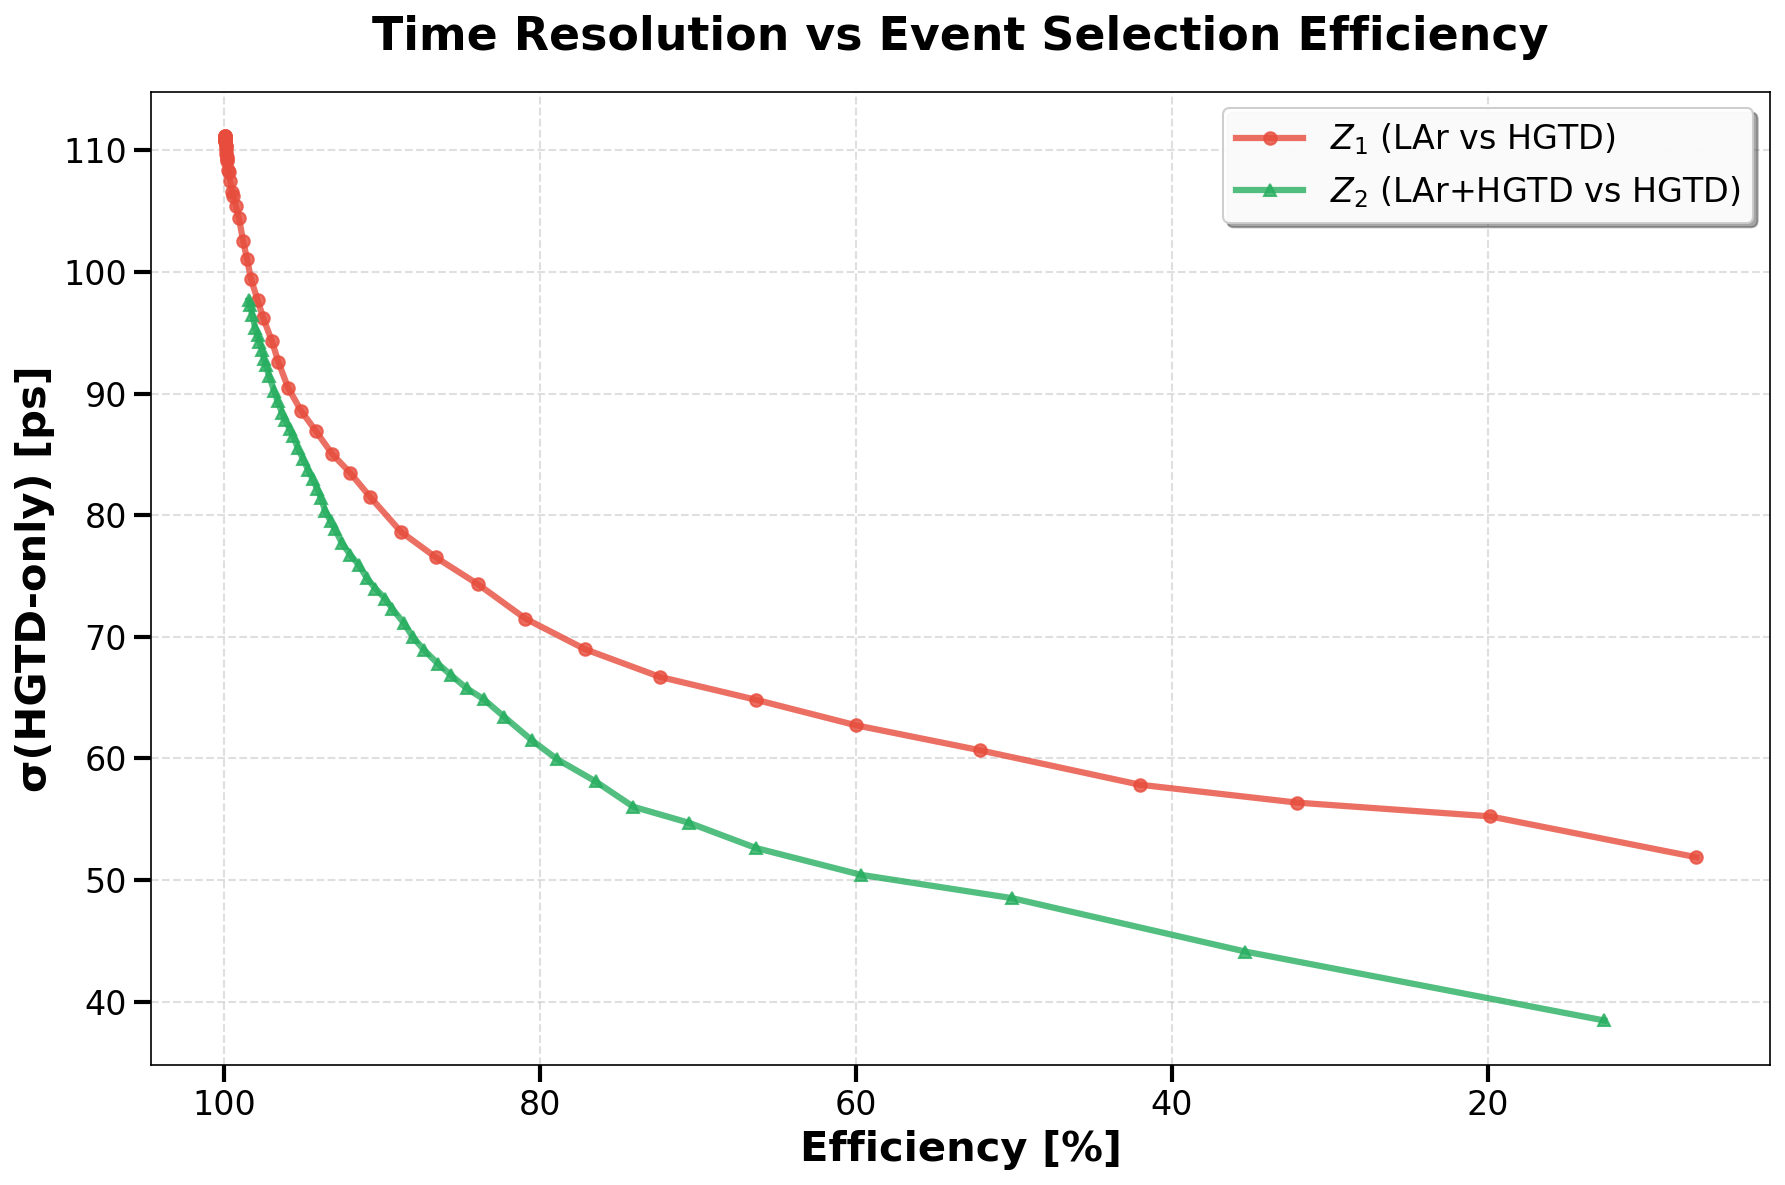

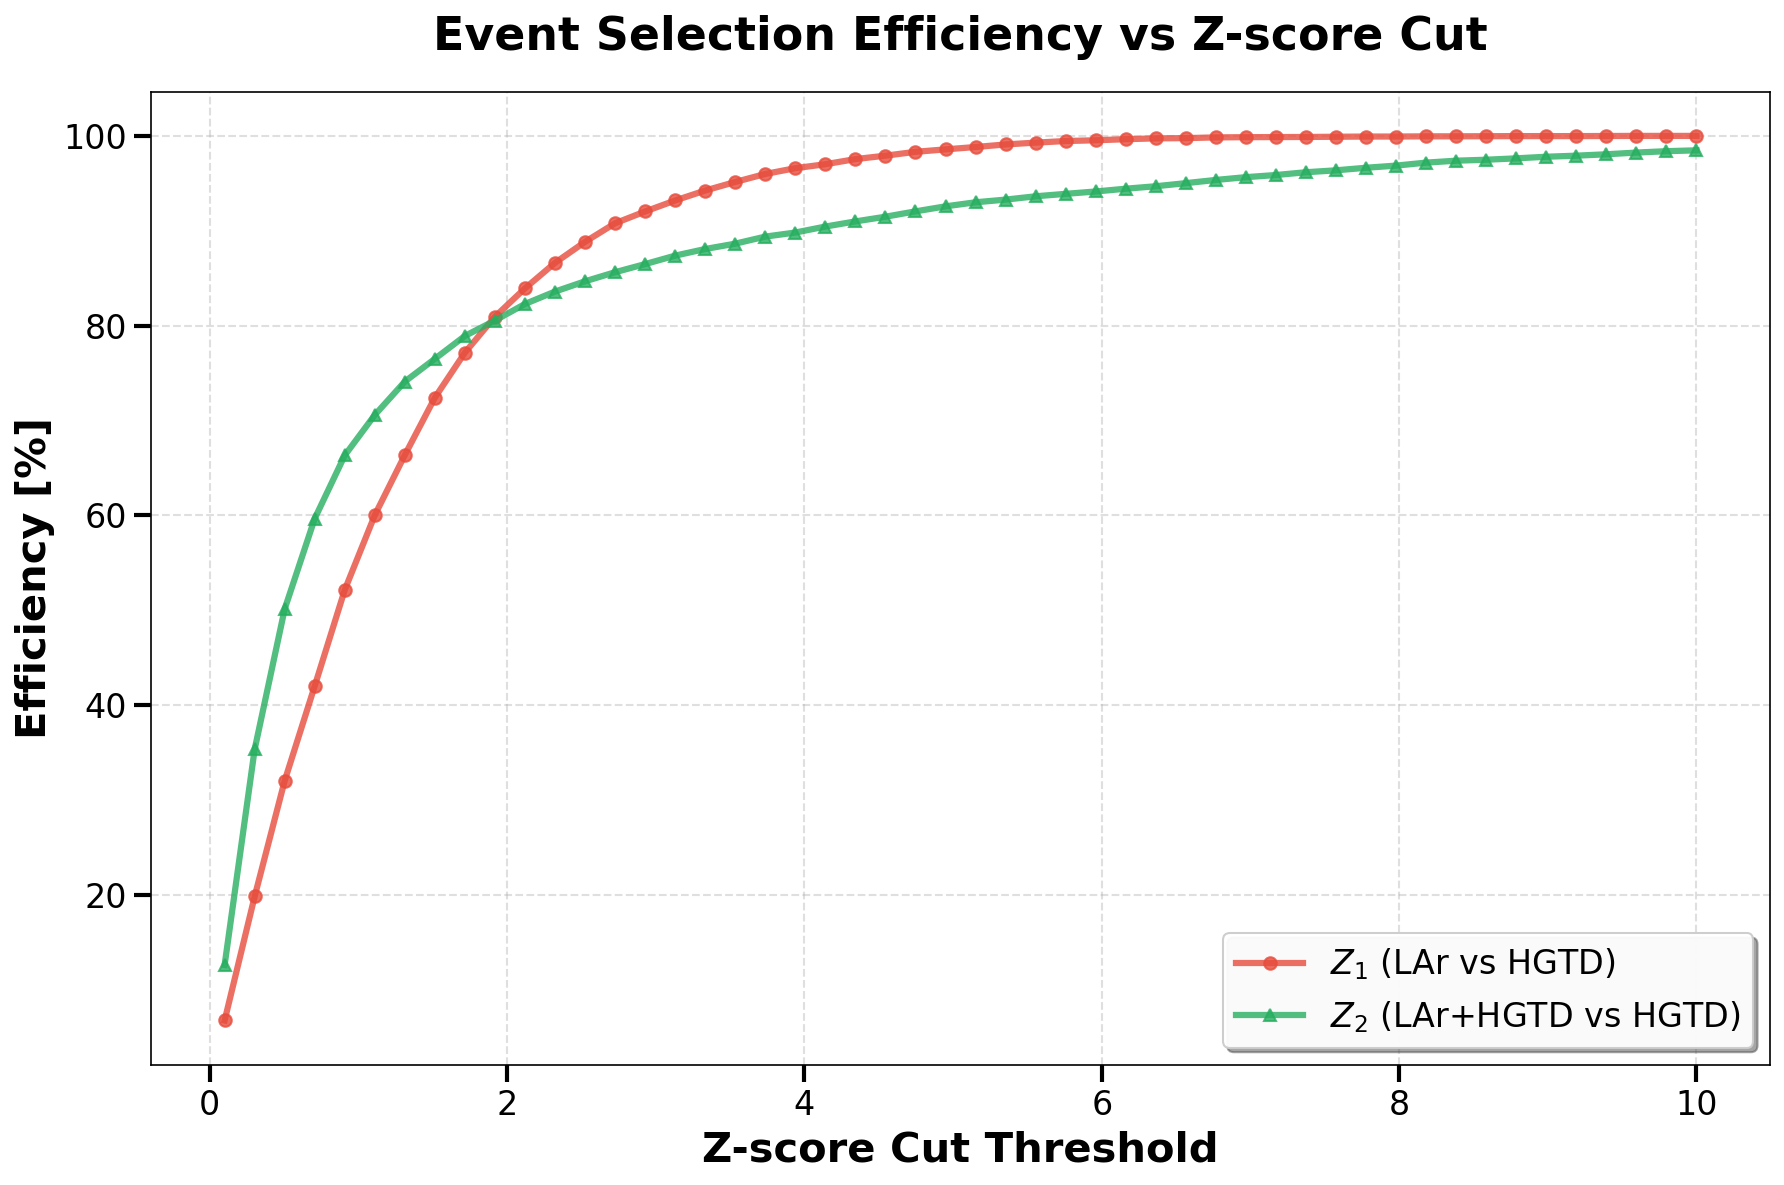


📊 Z-score Cut Performance Comparison
Z-cut      Strategy                  Efficiency [%]     σ [ps]          RMSE [ps]      
------------------------------------------------------------------------------------------
0.10       Z₁ (LAr vs HGTD)          6.77               51.878          51.838         
           Z₂ (LAr+HGTD vs HGTD)     12.62              38.459          38.442         
------------------------------------------------------------------------------------------
2.52       Z₁ (LAr vs HGTD)          88.82              78.636          78.632         
           Z₂ (LAr+HGTD vs HGTD)     84.67              65.775          65.795         
------------------------------------------------------------------------------------------
5.15       Z₁ (LAr vs HGTD)          98.82              102.536         102.561        
           Z₂ (LAr+HGTD vs HGTD)     92.99              78.836          78.845         
-------------------------------------------------------------------------

In [21]:
# Scan over different Z-score cut values
z_scan_values = np.linspace(0.1, 10.0, 50)  # Scan from 0.5 to 5.0

# Storage for Z_score only (LAr vs HGTD)
efficiencies_z1 = []
std_values_z1 = []
rmse_values_z1 = []

# Storage for Z_score_combined only (LAr+HGTD vs HGTD)
efficiencies_z2 = []
std_values_z2 = []
rmse_values_z2 = []

for z_threshold in z_scan_values:
    # Apply cut with Z_score only
    df_z1 = df[df['Z_score'] <= z_threshold]
    efficiencies_z1.append(len(df_z1) / len(df) * 100)
    std_values_z1.append(df_z1['Error (HGTD-only)'].std() if len(df_z1) > 0 else np.nan)
    rmse_values_z1.append(np.sqrt((df_z1['Error (HGTD-only)']**2).mean()) if len(df_z1) > 0 else np.nan)
    
    # Apply cut with Z_score_combined only
    df_z2 = df[df['Z_score_combined'] <= z_threshold]
    efficiencies_z2.append(len(df_z2) / len(df) * 100)
    std_values_z2.append(df_z2['Error (HGTD-only)'].std() if len(df_z2) > 0 else np.nan)
    rmse_values_z2.append(np.sqrt((df_z2['Error (HGTD-only)']**2).mean()) if len(df_z2) > 0 else np.nan)

# ====================================================================
# Figure 1: Std vs Efficiency
# ====================================================================
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

ax.plot(efficiencies_z1, std_values_z1, color='#e74c3c', linestyle='-', linewidth=3, 
        marker='o', markersize=6, label='$Z_1$ (LAr vs HGTD)', alpha=0.8)
ax.plot(efficiencies_z2, std_values_z2, color='#27ae60', linestyle='-', linewidth=3, 
        marker='^', markersize=6, label='$Z_2$ (LAr+HGTD vs HGTD)', alpha=0.8)

ax.set_xlabel('Efficiency [%]', fontsize=20, fontweight='bold')
ax.set_ylabel('σ(HGTD-only) [ps]', fontsize=20, fontweight='bold')
ax.set_title('Time Resolution vs Event Selection Efficiency', fontsize=22, fontweight='bold', pad=20)
ax.legend(fontsize=16, loc='best', frameon=True, shadow=True, fancybox=True, framealpha=0.95)
ax.grid(True, alpha=0.4, linestyle='--', linewidth=1)
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=8)
ax.invert_xaxis()

plt.tight_layout()
plt.show()

# ====================================================================
# Figure 2: Efficiency vs Z-cut threshold
# ====================================================================
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

ax.plot(z_scan_values, efficiencies_z1, color='#e74c3c', linestyle='-', linewidth=3, 
        marker='o', markersize=6, label='$Z_1$ (LAr vs HGTD)', alpha=0.8)
ax.plot(z_scan_values, efficiencies_z2, color='#27ae60', linestyle='-', linewidth=3, 
        marker='^', markersize=6, label='$Z_2$ (LAr+HGTD vs HGTD)', alpha=0.8)

ax.set_xlabel('Z-score Cut Threshold', fontsize=20, fontweight='bold')
ax.set_ylabel('Efficiency [%]', fontsize=20, fontweight='bold')
ax.set_title('Event Selection Efficiency vs Z-score Cut', fontsize=22, fontweight='bold', pad=20)
ax.legend(fontsize=16, loc='best', frameon=True, shadow=True, fancybox=True, framealpha=0.95)
ax.grid(True, alpha=0.4, linestyle='--', linewidth=1)
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=8)

plt.tight_layout()
plt.show()

# ====================================================================
# Print comparison at key points
# ====================================================================
print("\n📊 Z-score Cut Performance Comparison")
print("="*90)
print(f"{'Z-cut':<10} {'Strategy':<25} {'Efficiency [%]':<18} {'σ [ps]':<15} {'RMSE [ps]':<15}")
print("-"*90)
for i in [0, len(z_scan_values)//4, len(z_scan_values)//2, 3*len(z_scan_values)//4, -1]:
    print(f"{z_scan_values[i]:<10.2f} {'Z₁ (LAr vs HGTD)':<25} {efficiencies_z1[i]:<18.2f} {std_values_z1[i]:<15.3f} {rmse_values_z1[i]:<15.3f}")
    print(f"{'':10} {'Z₂ (LAr+HGTD vs HGTD)':<25} {efficiencies_z2[i]:<18.2f} {std_values_z2[i]:<15.3f} {rmse_values_z2[i]:<15.3f}")
    print("-"*90)